# Code Initialization

In [1]:
import stim
import random
import csv
import pandas as pd
import collections
import os
import json
import numpy as np

from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator, QasmSimulator, Aer

from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options, Sampler, SamplerV2, RuntimeEncoder, RuntimeDecoder

from qiskit.visualization import plot_histogram, plot_circuit_layout, plot_state_city
from qiskit.circuit.classical import expr
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError, reset_error,
    pauli_error, depolarizing_error, thermal_relaxation_error)
import qiskit.quantum_info as qi
from qiskit.qasm2 import dumps
from qiskit.circuit.library import RZZGate, RZGate, XGate, IGate
from qiskit.converters import circuit_to_dag, dag_to_circuit
# from qiskit.transpiler.passes import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling, PadDelay, PassManager
from qiskit.qasm2 import dumps
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from wrappers.polar_wrapper import (
        polar_code_p2, get_logical_error_on_accepted_states, divide_half_list
)

from wrappers.stim_wrapper import (
    convert_i_to_meas_type, generate_circuit_extraction_syndrome_stim, simulate_stim_polar_code, noisy_cx, noisy_h, noisy_x, noisy_z, 
    noisy_reset, noisy_measurement, calculate_logical_error_result_polar
    
)

token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")

# hw_name = "ibm_brisbane"
hw_name = "ibm_torino"
backend = service.backend(hw_name)

sim_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend)

## change later back to 3
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend
    #, seed_transpiler=12345
    )


qiskit_runtime_service._discover_account:WARNING:2025-11-17 10:46:13,417: Loading account with the given token. A saved account will not be used.


In [2]:
def get_backend_information(backend):

    properties = backend.properties()
    num_qubits = backend.num_qubits
    coupling_map = backend.coupling_map

    # We define various lists of metrics for all the qubits of the backend
    t1, t2, gate_error_x, readout_error, gate_error_cz = {}, {}, {}, {}, {}
    for i in range(num_qubits):
        # t1.append(properties.t1(i))
        # t2.append(properties.t2(i))
        # gate_error_x.append(properties.gate_error(gate="x", qubits=i))
        # readout_error.append(properties.readout_error(i))
        t1[i] = properties.t1(i)
        t2[i] = properties.t2(i)
        gate_error_x[i] = properties.gate_error(gate="x", qubits=i)
        readout_error[i] = properties.readout_error(i)

    for pair in coupling_map:
        gate_error_cz[pair] = properties.gate_error(gate="cz", qubits=pair)

    
    return t1, t2, gate_error_x, readout_error, gate_error_cz

# Stim Tableau

In [3]:
print("stim version :", stim.__version__)
sim = stim.TableauSimulator()


stim version : 1.15.0


In [4]:
counts = {}

for i in range(1000):
    # Step-by-step simulation using TableauSimulator
    sim = stim.TableauSimulator()
    p_error = 0

    noisy_h(sim, 0, p_error)
    noisy_cx(sim, 0, 1, p_error)
    noisy_cx(sim, 1, 2, p_error)
    noisy_cx(sim, 2, 3, p_error)

    # res0, kick0 = sim.measure_kickback(0)
    # print("Res:", res0, ", Kick:", kick0)
    
    # res1, kick1 = sim.measure_kickback(4)
    # print("Res:", res1, ", Kick:", kick1)

    final_measurements = sim.measure_many(0, 1, 2, 3)
    final_measurements

    bit_string = ''.join(['1' if b else '0' for b in final_measurements])
    bit_string

    if bit_string in counts:
        counts[bit_string] += 1
    else:
        counts[bit_string] = 1

counts

{'0000': 518, '1111': 482}

In [5]:
counts = {}

for i in range(1000):
    # Step-by-step simulation using TableauSimulator
    sim = stim.TableauSimulator()
    p_error = 0

    noisy_h(sim, 0, p_error)
    noisy_h(sim, 1, p_error)
    noisy_h(sim, 2, p_error)

    noisy_cx(sim, 2, 3, p_error)
    noisy_cx(sim, 1, 2, p_error)
    noisy_cx(sim, 0, 1, p_error)
    noisy_cx(sim, 2, 3, p_error)
    noisy_cx(sim, 1, 2, p_error)

    # res0, kick0 = sim.measure_kickback(0)
    # print("Res:", res0, ", Kick:", kick0)
    
    # res1, kick1 = sim.measure_kickback(4)
    # print("Res:", res1, ", Kick:", kick1)

    final_measurements = sim.measure_many(0, 1, 2, 3)
    final_measurements

    bit_string = ''.join(['1' if b else '0' for b in final_measurements])
    bit_string

    if bit_string in counts:
        counts[bit_string] += 1
    else:
        counts[bit_string] = 1

counts

{'1100': 135,
 '0111': 113,
 '0000': 136,
 '1011': 120,
 '1110': 127,
 '0101': 120,
 '0010': 117,
 '1001': 132}

## Polar Code

In [6]:
# str_data = "100"
# shots = 1000000

# seed_list = []
# for _ in range(shots):
#     seed_simulator = random.randint(1, 99999999)
#     seed_list.append(seed_simulator)

# df_result = pd.DataFrame({
#         'seed_list': seed_list,
#     })

# str_data = "1m"

# df_result.to_csv(f"./output/STIM/seed_list_{str_data}_3.csv")

In [7]:
def check_for_mismatch(syndrome_bits, n, x_ind, detection_layer = 1):
    """
    Helper function to check for a pattern mismatch in the measurement record.
    Returns True if a mismatch is found, False otherwise.
    d_layer = detection layer
    """
    expected_length = 2**(n - 1)
    
    full_bitstring = ''.join(['1' if b else '0' for b in syndrome_bits])
    
    # Extract the relevant portion of the syndrome for this layer.
    start_index = expected_length * detection_layer
    syndrome_to_check = full_bitstring[start_index:]
    
    bit_gap = 2**x_ind

    # print(len(full_bitstring), full_bitstring, syndrome_to_check, expected_length, bit_gap, x_ind)
    
    for i in range(expected_length):
        if (i % (2 * bit_gap)) < bit_gap:
            j = i + bit_gap
            if syndrome_to_check[i] != syndrome_to_check[j]:
                print(f"Mismatch found at indices ({i}, {j}) for string {syndrome_to_check}.")
                return True
            
    return False

In [8]:
def simulate_stim_polar_code(n, lstate, sim_type, i, p_error, shots, seeds, backend = None, initial_layout = None):
    """
    Simulates a quantum circuit for stabilizer code, simplified and optimized.

    Args:
        n (int): code length for polar code
        lstate (str): z for logical |0>, z for logical |+>
        sim_type: normal, m1, m2, m3
        p_error (float): The probability of an error occurring.
        shots (int): The number of simulation runs.
        seeds (list): A list of seeds for the simulator.
        i (int): An index used to determine measurement types (message location)

    Returns:
        dict: A dictionary of measurement outcome counts.
    """
    #m1 circuit simplify
    #m2 m1 + error detection
    #m3 m1 + error correction
    
    if backend != None:
        t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)
        cm = backend.coupling_map
    else:
        t1, t2, error_1q, readout_error, error_2q = None, None, None, None, None
        cm = None
    
    

    meas_type = convert_i_to_meas_type(i, n, lstate)
    N = 2**n
    ancilla_qubits = 2**(n - 1)

    counts = collections.Counter()
    bitstrings = []
    total_qubits = N + ancilla_qubits

    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    # print("index of the first x :", x_ind)
    # gap = 2**x_ind

    count_detect_discard = 0

    for shot_idx in range(shots):
        sim = stim.TableauSimulator(seed=seeds[shot_idx])

        error_detected_this_shot = False

        for level in range(1, n+1):

            # print(level, "-", meas_type[level - 1])
            
            num_loops = 2**(n - level)
            start_idx_mult = 2**(level) + 2**(level - 1)

            if sim_type in ["m1", "m2"] and level == x_ind + 1:
                x_first = True
            else:
                x_first = False

            if level <= x_ind:
                # skip the beginning of zz measurement
                # print("skip :" , level, x_ind)
                pass
            else:
                # print("num_loops :", num_loops)
                for loop_idx in range(num_loops):
                    start_idx = loop_idx * start_idx_mult
                    generate_circuit_extraction_syndrome_stim(sim, level, meas_type[level - 1], x_first, p_error=p_error, start_idx=start_idx,
                                                              error_1q=error_1q, error_2q=error_2q, initial_layout=initial_layout, cm=cm)
            
                # with the simplification, the first measurement will be always 0
                if not x_first:
                    for qb in range(2, total_qubits, 3): 
                        noisy_measurement(sim, qb, p_error, readout_error, initial_layout)
                        noisy_reset(sim, qb, p_error, error_1q, initial_layout)

            # add error detection
            # first error detection
            if sim_type in ["m2"] and level - x_ind == 2:
                cms = sim.current_measurement_record()
                # print(cms)

                detection_layer = 1
                if sim_type == "m2":
                    detection_layer -=1

                if check_for_mismatch(cms, n, x_ind, detection_layer):
                    error_detected_this_shot = True
                    break # Break from the `level` loop

        # if error is detected, skip the operation
        if error_detected_this_shot:
            count_detect_discard += 1
            continue # Continue to the next shot

        # Final measurements, simplified.
        for qb_idx in (j for j in range(total_qubits) if j % 3 != 2):
            if lstate == "x":
                noisy_h(sim, qb_idx, p_error, error_1q, initial_layout)
            noisy_measurement(sim, qb_idx, p_error, readout_error, initial_layout )
            

        final_measurements = sim.current_measurement_record()

        # Generate the bit string, reverse it, and update the counts.
        bit_string = ''.join(['1' if b else '0' for b in final_measurements])[::-1]

        if sim_type in ["m1", "m2"]:
            bit_string = bit_string + "0"*(2**(level - 1))
        

        # counts[bit_string] += 1
        bitstrings.append(bit_string)

    counts = collections.Counter(bitstrings)
    return counts
    # return bitstrings

In [9]:
n = 4
lstate = "x"
sim_type = "m1"
p_error = 0
i = 2
shots = 200
# seed_list = range(shots)
seed_list = range(shots)

counts = simulate_stim_polar_code(n, lstate, sim_type, i, p_error, shots, seed_list)

# counts = collections.Counter(results)
# print(len(results[0]), (results[0]))

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1
count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate.upper(), counts, zpos_list)

print(count_accept_n, shots - len(counts), count_accept_n / len(counts), 1 - ler_n)

# list_8 = []

# for c in counts:
#     list_8.append(c[-16:-8])
#     # list_8.append(c[0:8])

# counts_8 = collections.Counter(list_8)
# counts_8


# calculate_logical_error_result_polar(n, lstate, i, p_error, sim_type, shots)

200 57 1.3986013986013985 0.0


In [10]:
def simulate_batch_and_save_result_polar(n, lstate, sim_type, p_error, i, shots):

    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
    zpos_list[n] = i-1

    file_path = f"./output/STIM/polar_n{n}_{lstate}_{i}_{p_error}_{sim_type}.txt"

    existing_data = 0
    if os.path.exists(file_path):
        with open(file_path, "r") as f:
            lines = f.readlines()
            existing_data = len(lines)

    # shots = 1000
    seed_list = range(existing_data, existing_data + shots + 1)

    print(existing_data, seed_list[0], seed_list[-1])

    results = simulate_stim_polar_code(n, lstate, sim_type, i, p_error, shots, seed_list)

    with open(file_path, "a") as f:  # "a" means append mode
        f.write("\n".join(results) + "\n")

# count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate.upper(), counts_normal, zpos_list)
# print(sim_type, count_accept_n / shots, 1 - ler_n)



In [11]:
n = 4
lstate = "x"
sim_type = "normal"
p_error = 0
i = 7
shots = int(1e2)

simulate_batch_and_save_result_polar(n, lstate, sim_type, p_error, i, shots)

200 200 300


#### Retreive result

In [12]:
n = 4
lstate = "x"
i = 1
p_error = 0.01
sim_type = "m1"

def calculate_logical_error_result_polar(n, lstate, i, p_error, sim_type):
    file_path = f"./output/STIM/polar_n{n}_{lstate}_{i}_{p_error}_{sim_type}.txt"

    if not os.path.exists(file_path):
        return None  # skip missing files

    with open(file_path, "r") as f:
        lines = f.read().splitlines()

    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
    zpos_list[n] = i - 1

    counts = collections.Counter(lines)

    count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = \
        get_logical_error_on_accepted_states(
            n, lstate.upper(), counts, zpos_list
        )

    # Return structured result
    return {
        "n": n,
        "lstate": lstate,
        "i": i,
        "p_error": p_error,
        "sim_type": sim_type,
        "count_accept": count_accept_n,
        "count_logerror": count_logerror,
        "count_undecided": count_undecided,
        "LER": ler_n,
        "detect_normal": detect_normal,
        "decoding_normal": decoding_normal,
    }



## Qiskit Compilation

In [13]:
def generate_circuit_extraction_syndrome(k, meas_type, x_first = False):
    num_qbits = (2**k) + (2**(k-1))
    num_cbits = 2**(k-1)

    qc = QuantumCircuit(num_qbits, num_cbits)

    data_qubits = []
    ancillas = []
    for i in range(2**(k-1)):
        ancillas.append(i *3 + 2)

    for i in range(num_qbits):
        if i not in ancillas:
            data_qubits.append(i)

    d1, d2 = divide_half_list(data_qubits)
    #print(d1,d2, ancillas)

    for idx in range(len(d1)):

        if meas_type.lower() == "x":

            if x_first:
                qc.h(d1[idx])
                qc.cx(d1[idx], d2[idx])
            else:
                qc.h(ancillas[idx])
                qc.cx(ancillas[idx], d1[idx])
                qc.cx(ancillas[idx], d2[idx])
                qc.h(ancillas[idx])
                
                # qc.measure(ancillas[idx], idx)
                # qc.reset(ancillas[idx])

        elif meas_type.lower() == "z":
            qc.cx(d1[idx], ancillas[idx])
            qc.cx(d2[idx], ancillas[idx])

            # qc.measure(ancillas[idx], idx)
            # qc.reset(ancillas[idx])
    
    return qc

qc_x1 = generate_circuit_extraction_syndrome(1, "x", False)
qc_x1_first = generate_circuit_extraction_syndrome(1, "x", True)
qc_x2 = generate_circuit_extraction_syndrome(2, "x")
qc_x3 = generate_circuit_extraction_syndrome(3, "x")
qc_x4 = generate_circuit_extraction_syndrome(4, "x")
qc_x5 = generate_circuit_extraction_syndrome(5, "x")

qc_z2 = generate_circuit_extraction_syndrome(2, "z")
qc_z3 = generate_circuit_extraction_syndrome(3, "z")
qc_z4 = generate_circuit_extraction_syndrome(4, "z")
qc_z5 = generate_circuit_extraction_syndrome(5, "z")



#qc_x2.draw("mpl")



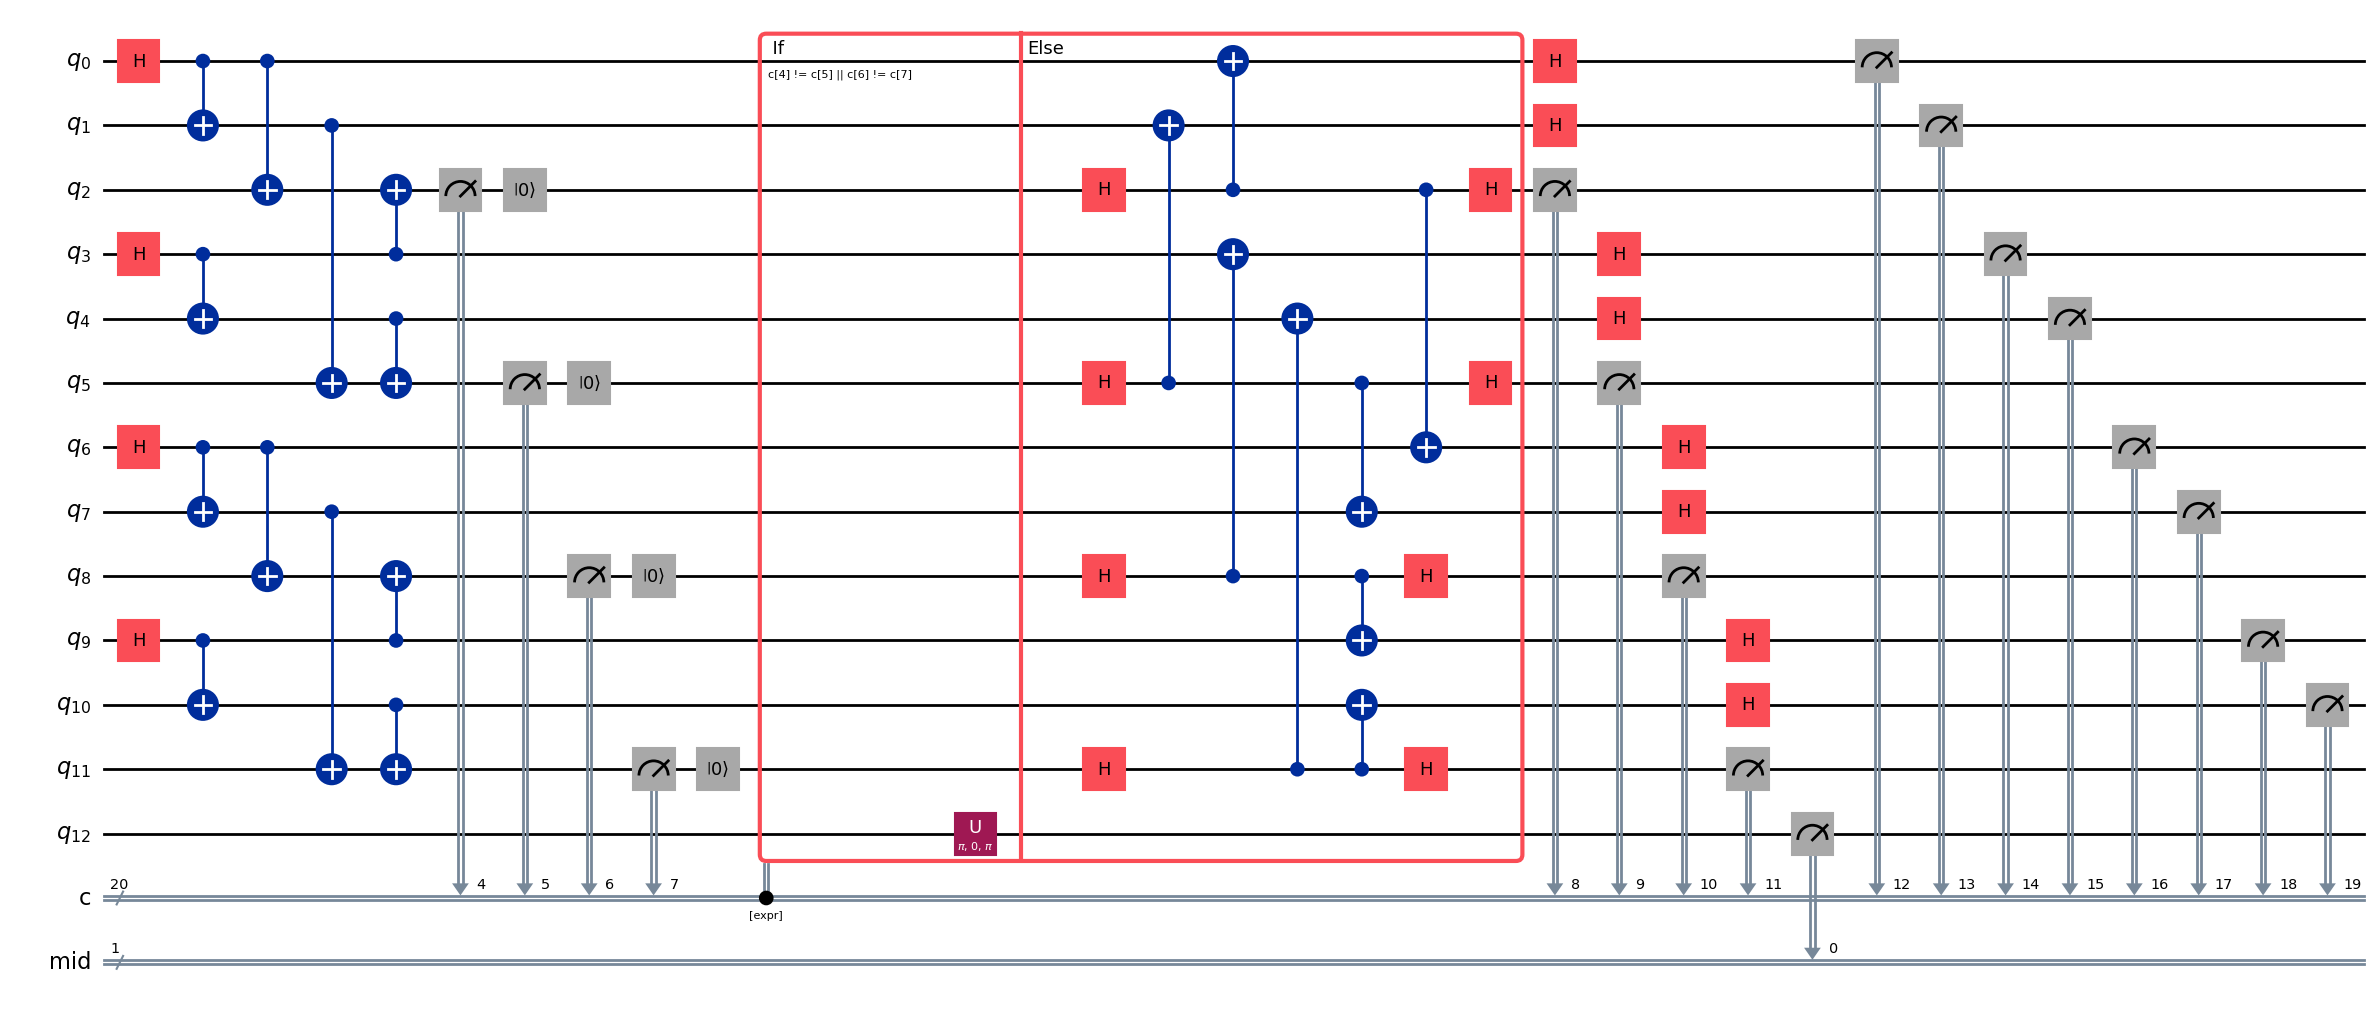

In [14]:
qreg = QuantumRegister(13, name="q")
creg = ClassicalRegister(20, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(4):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(2):
    start = i * 6 
    qc.append(qc_z2, range(start, start + 6), range(2))


m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    qc.reset(i)
    m_idx = m_idx + 1

# qc.barrier()

expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
with qc.if_test(expr_1) as else_:
    qc.x(12)
with else_:
    # qc.append(qc_z3, range(12), [8,9,10,11])
    qc.append(qc_x3, range(12), [8,9,10,11])

qc.measure(12, mid)

# m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    # qc.reset(i)
    m_idx = m_idx + 1

qc = qc.decompose()

# qc.barrier()

m_idx = 12
for i in range(12):
    if i in [2,5,8,11]:
        continue

    qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1

qc_dynamic_n3_x = qc
qc_dynamic_n3_x.draw("mpl", fold=-1)

In [15]:
def generate_qiskit_polar_code(n, lstate, sim_type, i):
    """
    Simulates a quantum circuit for stabilizer code, simplified and optimized.

    Args:
        n (int): code length for polar code
        lstate (str): z for logical |0>, z for logical |+>
        sim_type: normal, m1, m2, m3
        p_error (float): The probability of an error occurring.
        shots (int): The number of simulation runs.
        seeds (list): A list of seeds for the simulator.
        i (int): An index used to determine measurement types (message location)

    Returns:
        dict: A dictionary of measurement outcome counts.
    """
    #m1 circuit simplify
    #m2 m1 + error detection
    #m3 m1 + error correction
    
    meas_type = convert_i_to_meas_type(i, n, lstate)
    N = 2**n
    ancilla_qubits = 2**(n - 1)

    counts = collections.Counter()
    bitstrings = []
    total_qubits = N + ancilla_qubits

    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    # print("index of the first x :", x_ind)
    # gap = 2**x_ind

    count_detect_discard = 0
    cbits = ( ancilla_qubits * n ) + N
    qc = QuantumCircuit(total_qubits, cbits)
    error_detected_this_shot = False

    m_idx = 0
    for level in range(1, n+1):

        # print(level, "-", meas_type[level - 1])
        
        num_loops = 2**(n - level)
        start_idx_mult = 2**(level) + 2**(level - 1)

        if sim_type in ["m1", "m2"] and level == x_ind + 1:
            x_first = True
            m_idx += ancilla_qubits
            print("m_idx =", m_idx)
        else:
            x_first = False

        if level <= x_ind:
            # skip the beginning of zz measurement
            # print("skip :" , level, x_ind)
            # m_idx += ancilla_qubits
            # print("m_idx =", m_idx)
            pass
        else:
            # print("num_loops :", num_loops)
            for loop_idx in range(num_loops):
                start_idx = loop_idx * start_idx_mult
                circ = generate_circuit_extraction_syndrome(level, meas_type[level - 1], x_first)
                clbits = range(2**(level-1)) 

                # print(start_idx, level, clbits, total_qubits, cbits, start_idx_mult)
                qc.append(circ, range(start_idx, start_idx + start_idx_mult), clbits)
        
            # with the simplification, the first measurement will be always 0
            if not x_first:
                for qb in range(2, total_qubits, 3): 
                    qc.measure(qb, m_idx)
                    qc.reset(qb)
                    m_idx += 1


    qc = qc.decompose()
    # Final measurements, simplified.
    for qb_idx in (j for j in range(total_qubits) if j % 3 != 2):
        if lstate == "x":
            qc.h(qb_idx)
        qc.measure(qb_idx, m_idx)
        m_idx += 1
    
    return qc

In [16]:
def compiled_to_qiskit_hardware(hw_name, qc, optimization_level = 3):
    basis_gates = backend.configuration().basis_gates
    if 'cx' not in basis_gates:
        basis_gates = basis_gates + ['cx']
        basis_gates = basis_gates + ['h']

    sim_noisy = AerSimulator.from_backend(backend)

    ## change later back to 3
    pm = generate_preset_pass_manager(
        optimization_level=3, backend=sim_noisy,
        # basis_gates=basis_gates,
        #, seed_transpiler=12345
        )
    
    tqc = pm.run(qc)

    return tqc

m_idx = 4


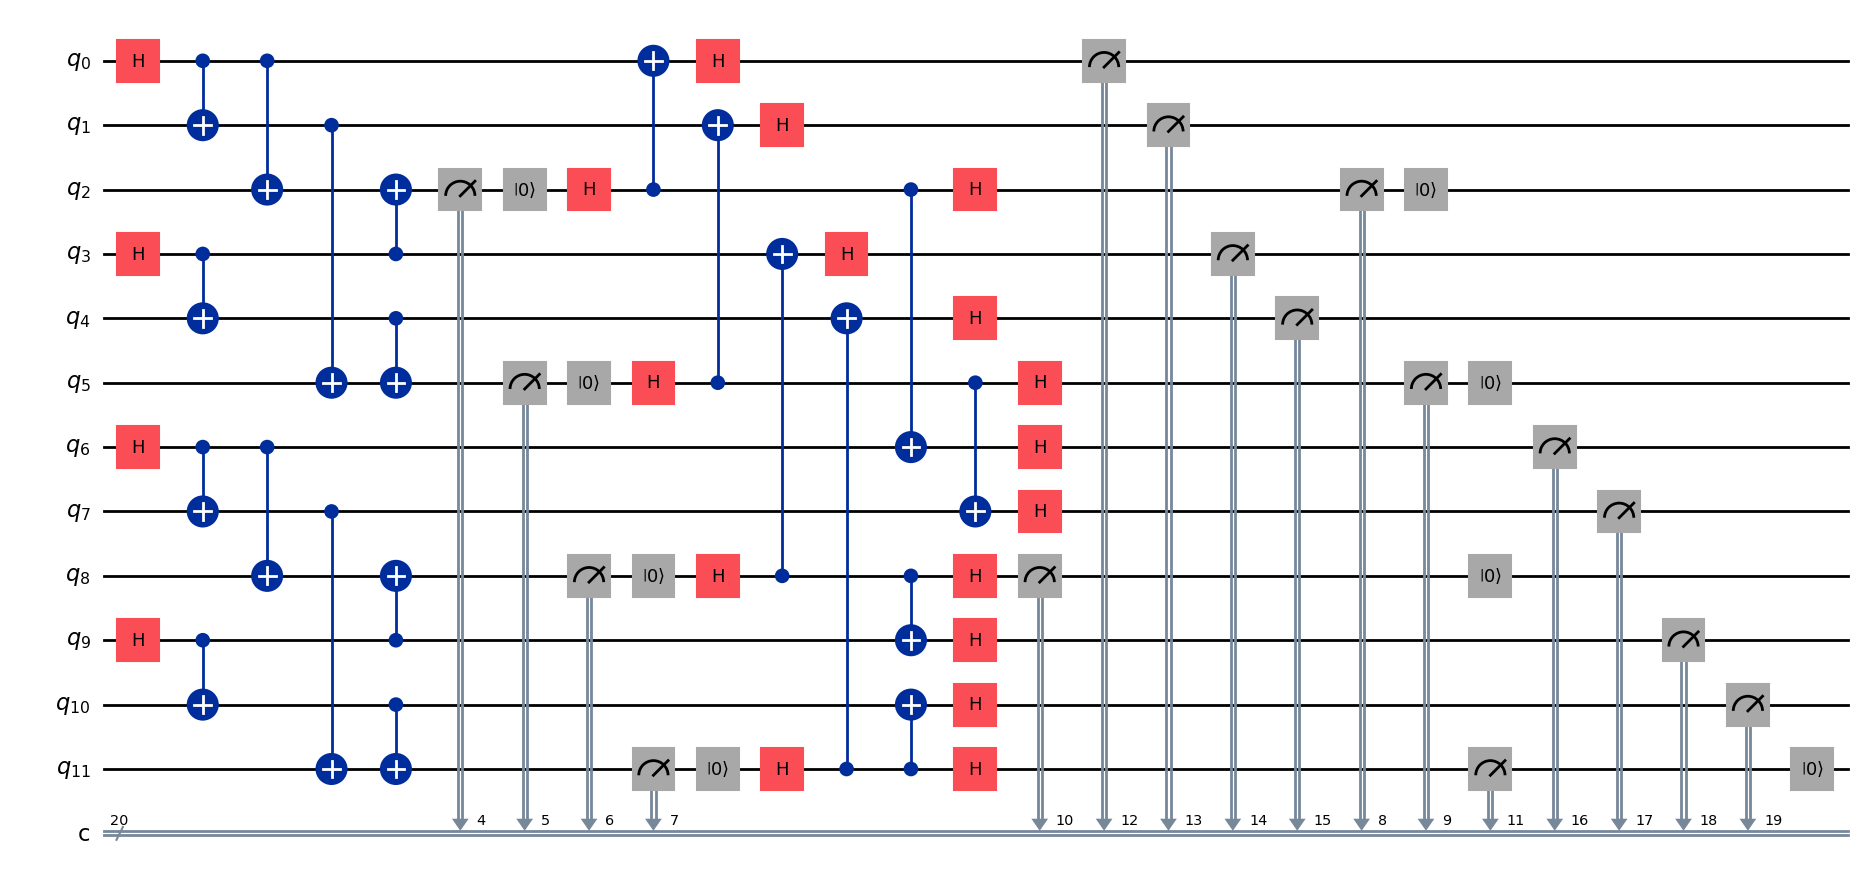

In [17]:
n = 3
i = 4
lstate = "x"

qc = generate_qiskit_polar_code(n, lstate, "m1", i)
qc.draw("mpl", fold=-1)

In [18]:
result = sim_ideal.run(qc, shots = 20000).result()
counts = result.get_counts()

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i - 1

count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = \
        get_logical_error_on_accepted_states(
            n, lstate.upper(), counts, zpos_list
        )

count_accept_n


20000

In [19]:
# sum_middle_digits_dict(counts, None, )

In [20]:
from commons import (
    used_qubits, sum_middle_digits_dict
)

# res = sum_middle_digits_dict(counts, 8, 20)
m_1 = {}
m_2 = {}
m_3 = {}
m_4 = {}
sisa = {}
for key, value in counts.items():
    # print(key, key[-4:], key[-8:-4], key[-12:-8], key[-20:-12])
    # if key[-4:] == "0000":
    #     m_1[key[-4:]] = 1
    #     m_2[key[-8:-4]] = 1
    #     m_3[key[-12:-8]] = 1
    #     m_4[key[-20:-12]] = 1

    if key[-12:-8] == "0000":
        sisa[key[-20:-12]] = 1

    m_1[key[-4:]] = 1
    m_2[key[-8:-4]] = 1
    m_3[key[-12:-8]] = 1
    m_4[key[-20:-12]] = 1

In [21]:
sisa

{'11111111': 1,
 '10101010': 1,
 '10011001': 1,
 '00110011': 1,
 '00000000': 1,
 '11001100': 1,
 '01010101': 1,
 '01100110': 1}

#### Playing with Noise Information

In [22]:
# noise_model = NoiseModel.from_backend(backend)


In [23]:

tqc = compiled_to_qiskit_hardware("ibm_torino", qc, 3)
initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)
initial_layout

# result = sim_ideal.run(tqc, shots = 1000).result()
# counts = result.get_counts()

# zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
# zpos_list[n] = i - 1

# count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = \
#         get_logical_error_on_accepted_states(
#             n, lstate.upper(), counts, zpos_list
#         )

# count_accept_n

[33, 32, 51, 48, 36, 29, 50, 49, 56, 46, 55, 47]

In [24]:
tqc.draw(fold=-1)
# ttqc = transpile(tqc, basis_gates=['u', 'cx'], optimization_level=0)
# ttqc.draw(fold=-1, idle_wires=False)

global phase: π
                 ┌─────────┐   ┌────┐      ┌───────┐                                                                                                                                                        ┌────┐┌─────────┐                                                       ┌─┐           ┌─────────┐   ┌────┐  ┌───────┐                               ┌────┐┌─────────┐                               ┌─┐                                                                                                                                                                    
       q_5 -> 29 ┤ Rz(π/2) ├───┤ √X ├──────┤ Rz(π) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────────■─┤ √X ├┤ Rz(π/2) ├───────────────────────────────────────────────────────┤M├────|0>────┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────■───────────────────────■─┤ √X ├┤ Rz(π/2) ├───────────────────────────────┤M├────|0>─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                 └──┬────┬─┘   └────┘      └───────┘                                                                                                ┌────┐             ┌────┐           │     ┌─────────┐ │ ├────┤├─────────┤                                                       └╥┘           └─────────┘   └────┘  └───────┘     │                       │ └┬─┬─┘└─────────┘                               └╥┘                                                                                                                                                                    
ancilla_77 -> 30 ───┤ √X ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────■──────────┤ √X ├──────■──────┤ √X ├────■──────■─────┤ Rz(π/2) ├─┼─┤ √X ├┤ Rz(π/2) ├────────────────────────────────────────────────────────╫────────────────────────────────────────────────■───────────────────────┼──┤M├─────────────────────────────────────────────╫─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                    ├────┤                                                               ┌────┐             ┌────┐            ┌────┐     │          ├────┤      │      ├────┤    │            └─────────┘ │ └────┘└─────────┘                                                        ║                                                                        │  └╥┘                                             ║                                                                                                                                                                     
ancilla_78 -> 31 ───┤ √X ├──────────────────────────────────────────────────────■────────┤ √X ├───────■─────┤ √X ├─────■──────┤ √X ├─────■──────────┤ √X ├──────■──────┤ √X ├────■────────────────────────┼──────────────────────────────────────────────────────────────────────────╫────────────────────────────────────────────────────────────────────────┼───╫──────────────────────────────────────────────╫─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                 ┌──┴────┴─┐   ┌────┐     ┌──────────┐    ┌────┐┌─────────┐     │        ├────┤       │     ├────┤     │      └────┘                └────┘             └────┘                             │                                                                          ║                                                                        │   ║                                              ║                                                                                                                                                                     
       q

In [25]:
# initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)
# for g in tqc:
#     op = g.operation
#     qubs = g.qubits
#     clbs = g.clbits
#     q1_idx = qubs[0]._index

#     if op.name == "h":
#         print(op.name, qubs[0])
#         pass
#     elif op.name == "cx":
#         q2_idx = qubs[1]._index
#         # print(op.name, qubs[0]._index, qubs[1]._index)
#         pass
#     elif op.name == "measure":
#         # print(op.name, qubs[0], q1_idx, initial_layout[q1_idx], clbs)
#         pass

#### Playing with Layout

In [26]:
from qiskit.transpiler import TranspileLayout

lay: TranspileLayout = tqc.layout
print(lay.initial_index_layout(filter_ancillas=True))
print(lay.final_index_layout(filter_ancillas=True))
# lay.initial_virtual_layout(filter_ancillas=True)
# lay.final_virtual_layout(filter_ancillas=True)

[33, 32, 51, 48, 36, 29, 50, 49, 56, 46, 55, 47]
[52, 30, 50, 51, 47, 29, 56, 36, 49, 48, 55, 46]


In [27]:
print(lay.routing_permutation())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 30, 52, 34, 35, 47, 33, 38, 39, 40, 41, 42, 43, 44, 45, 48, 46, 51, 36, 56, 50, 37, 53, 54, 55, 49, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132]


In [28]:
tqc.draw(fold=-1)

global phase: π
                 ┌─────────┐   ┌────┐      ┌───────┐                                                                                                                                                        ┌────┐┌─────────┐                                                       ┌─┐           ┌─────────┐   ┌────┐  ┌───────┐                               ┌────┐┌─────────┐                               ┌─┐                                                                                                                                                                    
       q_5 -> 29 ┤ Rz(π/2) ├───┤ √X ├──────┤ Rz(π) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────────■─┤ √X ├┤ Rz(π/2) ├───────────────────────────────────────────────────────┤M├────|0>────┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────■───────────────────────■─┤ √X ├┤ Rz(π/2) ├───────────────────────────────┤M├────|0>─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                 └──┬────┬─┘   └────┘      └───────┘                                                                                                ┌────┐             ┌────┐           │     ┌─────────┐ │ ├────┤├─────────┤                                                       └╥┘           └─────────┘   └────┘  └───────┘     │                       │ └┬─┬─┘└─────────┘                               └╥┘                                                                                                                                                                    
ancilla_77 -> 30 ───┤ √X ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────■──────────┤ √X ├──────■──────┤ √X ├────■──────■─────┤ Rz(π/2) ├─┼─┤ √X ├┤ Rz(π/2) ├────────────────────────────────────────────────────────╫────────────────────────────────────────────────■───────────────────────┼──┤M├─────────────────────────────────────────────╫─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                    ├────┤                                                               ┌────┐             ┌────┐            ┌────┐     │          ├────┤      │      ├────┤    │            └─────────┘ │ └────┘└─────────┘                                                        ║                                                                        │  └╥┘                                             ║                                                                                                                                                                     
ancilla_78 -> 31 ───┤ √X ├──────────────────────────────────────────────────────■────────┤ √X ├───────■─────┤ √X ├─────■──────┤ √X ├─────■──────────┤ √X ├──────■──────┤ √X ├────■────────────────────────┼──────────────────────────────────────────────────────────────────────────╫────────────────────────────────────────────────────────────────────────┼───╫──────────────────────────────────────────────╫─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                 ┌──┴────┴─┐   ┌────┐     ┌──────────┐    ┌────┐┌─────────┐     │        ├────┤       │     ├────┤     │      └────┘                └────┘             └────┘                             │                                                                          ║                                                                        │   ║                                              ║                                                                                                                                                                     
       q

In [29]:
tqc.count_ops()

OrderedDict([('sx', 98),
             ('rz', 71),
             ('cz', 51),
             ('measure', 16),
             ('reset', 8),
             ('x', 1)])

In [30]:
qc.count_ops()

OrderedDict([('h', 20), ('cx', 20), ('measure', 16), ('reset', 8)])

#### Simulate with Qiskit Initial Layout

In [31]:
n = 3
lstate = "x"
sim_type = "m1"
p_error = 1
i = 4
shots = 1000

lstate = "x"

qc = generate_qiskit_polar_code(n, lstate, "m1", i)
tqc = compiled_to_qiskit_hardware("ibm_torino", qc, 3)
initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)
initial_layout

m_idx = 4


[17, 29, 8, 27, 28, 30, 11, 12, 9, 10, 18, 31]

In [32]:

# seed_list = range(shots)
seed_list = range(shots)

counts = simulate_stim_polar_code(n, lstate, sim_type, i, p_error, shots, seed_list, backend, initial_layout)

# counts = collections.Counter(results)
# print(len(results[0]), (results[0]))

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1
count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate.upper(), counts, zpos_list)

print(count_accept_n, shots - sum(counts.values()), count_accept_n / sum(counts.values()), 1 - ler_n)

# list_8 = []

# for c in counts:
#     list_8.append(c[-16:-8])
#     # list_8.append(c[0:8])

# counts_8 = collections.Counter(list_8)
# counts_8


# calculate_logical_error_result_polar(n, lstate, i, p_error, sim_type)

639 0 0.639 0.0938967136150235


In [33]:
t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)
error_2q[(45, 46)], error_2q[(46, 47)]

(0.003777049563371354, 0.002210141285778233)

In [34]:
cm = backend.coupling_map

In [35]:
cm.distance(45, 47)

2

In [36]:
path = cm.shortest_undirected_path(45, 47)
path_pairs = list(zip(path[:-1], path[1:]))

print(path_pairs)

[(45, 46), (46, 47)]


In [37]:
path_pairs = list(zip(path[:-1], path[1:]))

fid_total = 1
for pair in path_pairs:
    fid_total *= (1 - error_2q[pair])
    print(fid_total, 1 - error_2q[pair])

error_rate = (1 - fid_total) 
error_rate * 0.1


0.9962229504366287 0.9962229504366287
0.9940211569640289 0.9977898587142218


0.0005978843035971071

In [38]:
backend.name

'ibm_torino'

In [39]:
# error_1q, readout_error, error_2q

import csv

# Your data
data = error_1q
csv_file_path = './output/error_information/ibm_torino_20251002_error_1q.csv'

# Define the column headers
fieldnames = ['Qubit', 'Error_Rate']

# Convert the dictionary into a list of rows (list of dictionaries)
# Each dictionary represents one row in the CSV
rows = [{'Qubit': k, 'Error_Rate': v} for k, v in data.items()]

with open(csv_file_path, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    # Write the header and the data
    writer.writeheader()
    writer.writerows(rows)

print(f"Successfully saved data to {csv_file_path} using the 'csv' module. ✅")

# 1. Read the CSV file
df = pd.read_csv(csv_file_path)

# 2. Convert the two-column DataFrame directly to a dictionary
# 'Qubit' is the column containing the keys (index), and 'Error_Rate' is the column containing the values.
error_dict = df.set_index('Qubit')['Error_Rate'].to_dict()

# Print the result
print(error_dict)

Successfully saved data to ./output/error_information/ibm_torino_20251002_error_1q.csv using the 'csv' module. ✅
{0: 0.0003190215869524, 1: 0.0001605858609919, 2: 0.0006228784344822, 3: 0.0001820516667231, 4: 0.0002370316600178, 5: 0.0002202390418875, 6: 0.000544674397283, 7: 0.0006486606016389, 8: 0.0004588780422717, 9: 0.0003411138853507, 10: 0.000137194790419, 11: 0.0001622260932737, 12: 9.736341267563646e-05, 13: 0.0001916576776502, 14: 0.0004841546585445, 15: 0.0007285315480923, 16: 0.0001307737996126, 17: 0.0005302842771945, 18: 0.0003482896713937, 19: 0.0010118488506844, 20: 0.0002721774548281, 21: 0.0004713189054548, 22: 0.0004143711646861, 23: 0.0001211571099823, 24: 0.0002605492715185, 25: 0.0003585084532281, 26: 0.0014254825350464, 27: 0.0002642156995963, 28: 0.0002211761090263, 29: 0.0002553425578921, 30: 0.0001659476060088, 31: 0.0001605290583371, 32: 0.000174111146028, 33: 0.0009661965570115, 34: 0.000292392779346, 35: 0.0003828744551139, 36: 0.0005903353620767, 37: 0.000

In [40]:
# Your data
data = readout_error
csv_file_path = './output/error_information/ibm_torino_20251002_readout_error.csv'

# Define the column headers
fieldnames = ['Qubit', 'Error_Rate']

# Convert the dictionary into a list of rows (list of dictionaries)
# Each dictionary represents one row in the CSV
rows = [{'Qubit': k, 'Error_Rate': v} for k, v in data.items()]

with open(csv_file_path, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    # Write the header and the data
    writer.writeheader()
    writer.writerows(rows)

print(f"Successfully saved data to {csv_file_path} using the 'csv' module. ✅")

# 1. Read the CSV file
df = pd.read_csv(csv_file_path)

# 2. Convert the two-column DataFrame directly to a dictionary
# 'Qubit' is the column containing the keys (index), and 'Error_Rate' is the column containing the values.
error_dict = df.set_index('Qubit')['Error_Rate'].to_dict()

# Print the result
print(error_dict)

Successfully saved data to ./output/error_information/ibm_torino_20251002_readout_error.csv using the 'csv' module. ✅
{0: 0.1468505859375, 1: 0.06103515625, 2: 0.1031494140625, 3: 0.019775390625, 4: 0.043212890625, 5: 0.0277099609375, 6: 0.0155029296875, 7: 0.0762939453125, 8: 0.0595703125, 9: 0.0191650390625, 10: 0.0457763671875, 11: 0.005126953125, 12: 0.0218505859375, 13: 0.02587890625, 14: 0.03662109375, 15: 0.0181884765625, 16: 0.0264892578125, 17: 0.0084228515625, 18: 0.0089111328125, 19: 0.04833984375, 20: 0.0185546875, 21: 0.0726318359375, 22: 0.032470703125, 23: 0.0582275390625, 24: 0.02685546875, 25: 0.113037109375, 26: 0.0445556640625, 27: 0.0499267578125, 28: 0.00537109375, 29: 0.0238037109375, 30: 0.0084228515625, 31: 0.103271484375, 32: 0.0181884765625, 33: 0.038330078125, 34: 0.0428466796875, 35: 0.0152587890625, 36: 0.0059814453125, 37: 0.00732421875, 38: 0.0660400390625, 39: 0.03515625, 40: 0.017333984375, 41: 0.06982421875, 42: 0.1376953125, 43: 0.010986328125, 44: 0.

In [41]:
# Your data
data = error_2q
csv_file_path = './output/error_information/ibm_torino_20251002_error_2q.csv'

# Define the column headers
fieldnames = ['Qubit', 'Error_Rate']

# Convert the dictionary into a list of rows (list of dictionaries)
# Each dictionary represents one row in the CSV
rows = [{'Qubit': k, 'Error_Rate': v} for k, v in data.items()]

with open(csv_file_path, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    # Write the header and the data
    writer.writeheader()
    writer.writerows(rows)

print(f"Successfully saved data to {csv_file_path} using the 'csv' module. ✅")

# 1. Read the CSV file
df = pd.read_csv(csv_file_path)

# 2. Convert the two-column DataFrame directly to a dictionary
# 'Qubit' is the column containing the keys (index), and 'Error_Rate' is the column containing the values.
error_dict = df.set_index('Qubit')['Error_Rate'].to_dict()

# Print the result
print(error_dict)

Successfully saved data to ./output/error_information/ibm_torino_20251002_error_2q.csv using the 'csv' module. ✅
{'(0, 1)': 0.0019091232022513, '(0, 15)': 0.0078044524984998, '(1, 0)': 0.0019091232022513, '(1, 2)': 0.0021531962841691, '(2, 1)': 0.0021531962841691, '(2, 3)': 0.0017313818118752, '(3, 2)': 0.0017313818118752, '(3, 4)': 0.0028599788509987, '(4, 3)': 0.0028599788509987, '(4, 5)': 0.0027491488141509, '(4, 16)': 0.0021640706665986, '(5, 4)': 0.0027491488141509, '(5, 6)': 0.002607832754263, '(6, 5)': 0.002607832754263, '(6, 7)': 0.002798161992881, '(7, 6)': 0.002798161992881, '(7, 8)': 0.0029460958114602, '(8, 7)': 0.0029460958114602, '(8, 9)': 0.0031809471948421, '(8, 17)': 0.0031135127921137, '(9, 8)': 0.0031809471948421, '(9, 10)': 0.0023157142396413, '(10, 9)': 0.0023157142396413, '(10, 11)': 0.0012572957942556, '(11, 10)': 0.0012572957942556, '(11, 12)': 0.0033501870334229, '(12, 11)': 0.0033501870334229, '(12, 13)': 0.0013873646493529, '(12, 18)': 0.0011740832319912, '(1

In [42]:
error_dict[str((0,1))]

0.0019091232022513

## Experiment: Concatenated code with repetition code

#### simulate_n4_4_x

In [43]:
def simulate_n4_4_x_normal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

        for i in range(8):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(4):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(2):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
        for i in range(1):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(24) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [44]:
def simulate_n4_4_x_proposal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

# part 1 --------------------------------
        for i in range(4):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", True, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            # noisy_measurement(sim, qb, p_error)
            # noisy_reset(sim, qb, p_error)
            sim.measure(14)

# part 2 --------------------------------

        for i in range(2):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "z", False, p_error=p_error, start_idx=start_idx)

        # for qb in range(2, 12, 3): 
        #     noisy_measurement(sim, qb, p_error)
        #     noisy_reset(sim, qb, p_error)

        # for qb in range(14, 24, 3): 
        #     sim.measure(14)

        # ----- This is for i = 4, xzxx --------------------------------
        noisy_h(sim, 12, p=p_error)
        noisy_cx(sim, 12, 15, p=p_error)
        noisy_h(sim, 13, p=p_error)
        noisy_cx(sim, 13, 16, p=p_error)
        noisy_h(sim, 18, p=p_error)
        noisy_cx(sim, 18, 21, p=p_error)
        noisy_h(sim, 19, p=p_error)
        noisy_cx(sim, 19, 22, p=p_error)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
        # ----- This is for i = 4, xzxx --------------------------------

# part 3 --------------------------------

        for i in range(2):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "x", False, p_error=p_error, start_idx=start_idx)


        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
# part 4 --------------------------------

        for i in range(1):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(24) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [45]:
# p_error = 0.001
# shots = 1000
# seeds = range(shots)
# counts_normal, bs_normal = simulate_n4_6_x_normal(p_error, shots, seeds)
# counts_proposal, bs_proposal = simulate_n4_6_x_proposal(p_error, shots, seeds)

# zpos_list = [-1, -1, 1, 3, 3, 7, 22, 15, 90, 31, 362]

# n = 4
# lstate = "X"
# count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_normal, zpos_list)
# print(count_accept_n, count_accept_n / shots, 1 - ler_n, count_logerror, count_undecided)

# count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_proposal, zpos_list)
# print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

#### simulate_n4_6_x : xxzx

In [46]:
def simulate_n4_6_x_normal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

        for i in range(8):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(4):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(2):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
        for i in range(1):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(24) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [47]:
def simulate_n4_6_x_proposal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

# part 1 --------------------------------
        for i in range(4):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", True, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            sim.measure(14)

# part 2 --------------------------------

        for i in range(2):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 12, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for qb in range(14, 24, 3): 
            sim.measure(14)


# part 3 --------------------------------

        for i in range(1):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "z", False, p_error=p_error, start_idx=start_idx)

        # Note: jump 6 at part 3
        noisy_h(sim, 12, p=p_error)
        noisy_cx(sim, 12, 18, p=p_error)
        noisy_h(sim, 13, p=p_error)
        noisy_cx(sim, 13, 19, p=p_error)
        noisy_h(sim, 15, p=p_error)
        noisy_cx(sim, 15, 21, p=p_error)
        noisy_h(sim, 16, p=p_error)
        noisy_cx(sim, 16, 22, p=p_error)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
# part 4 --------------------------------

        for i in range(1):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(24) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [48]:
p_error = 0
shots = 1000
seeds = range(shots)
counts_normal, bs_normal = simulate_n4_6_x_normal(p_error, shots, seeds)
counts_proposal, bs_proposal = simulate_n4_6_x_proposal(p_error, shots, seeds)

zpos_list = [-1, -1, 1, 3, 5, 7, 22, 15, 90, 31, 362]

n = 4
lstate = "X"
count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_normal, zpos_list)
print(count_accept_n, count_accept_n / shots, 1 - ler_n, count_logerror, count_undecided)

count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_proposal, zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

1000 1.0 0.0 0 0
1000 1.0 0.0 0 0


In [49]:
# shots = 100000 (For x)
# p_error = 0.01, i = 4 xzxx
# 26760 0.2676 0.005194319880418519 139 270
# 37204 0.37204 0.004515643479195752 168 329

# p_error = 0.001, i = 4 xzxx
# 87532 0.87532 4.5697573458847174e-05 4 9
# 90633 0.90633 4.413403506453584e-05 4 9

# p_error = 0.01, i = 6 xxzx
# 26416 0.26416 0.008593276801938221 227 438 normal
# 45611 0.45611 0.007827059262020097 357 692 prop

# p_error = 0.001, i = 6 xxzx
# 87272 0.87272 6.875057292143882e-05 6 13 normal
# 92341 0.92341 4.331770286225556e-05 4 7 prop

In [50]:
def simulate_n4_6_z_normal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

        # for i in range(8):
        #     start_idx = i * 3 
        #     generate_circuit_extraction_syndrome_stim(sim, 1, "z", False, p_error=p_error, start_idx=start_idx)

        # for qb in range(2, 24, 3): 
        #     noisy_measurement(sim, qb, p_error)
        #     noisy_reset(sim, qb, p_error)

        for i in range(4):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(2):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
        for i in range(1):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(24) if j % 3 != 2):
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [51]:
def simulate_n4_4_x_normal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

        for i in range(8):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(4):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(2):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
        for i in range(1):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(24) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [52]:
# def simulate_n4_10_z_proposal(p_error, shots, seeds):

#     counts = {}
#     bitstrings = []
#     # p_error = 0.0001
#     # shots = 100000
#     for i in range(shots):
#         sim = stim.TableauSimulator(seed=seeds[i])

#         # for i in range(8):
#         #     start_idx = i * 3 
#         #     generate_circuit_extraction_syndrome_stim(sim, 1, "z", False, p_error=p_error, start_idx=start_idx)

#         # for qb in range(2, 24, 3): 
#         #     noisy_measurement(sim, qb, p_error)
#         #     noisy_reset(sim, qb, p_error)

#         for i in range(2):
#             start_idx = i * 6 
#             generate_circuit_extraction_syndrome_stim(sim, 2, "x", True, p_error=p_error, start_idx=start_idx)

#         for qb in range(2, 12, 3): 
#             noisy_measurement(sim, qb, p_error)
#             noisy_reset(sim, qb, p_error)

#         for qb in range(14, 24, 3): 
#             sim.measure(14)

#         for i in range(1):
#             start_idx = i * 12 
#             generate_circuit_extraction_syndrome_stim(sim, 3, "x", False, p_error=p_error, start_idx=start_idx)


#         for qb in range(2, 24, 3): 
#             noisy_measurement(sim, qb, p_error)
#             noisy_reset(sim, qb, p_error)
            
#         for i in range(1):
#             start_idx = i * 24 
#             generate_circuit_extraction_syndrome_stim(sim, 4, "z", False, p_error=p_error, start_idx=start_idx)

#         for qb in range(2, 24, 3): 
#             noisy_measurement(sim, qb, p_error)
#             noisy_reset(sim, qb, p_error)

#         for i in (j for j in range(24) if j % 3 != 2):
#             noisy_measurement(sim, i, p_error)

#         # final_measurements = sim.measure_many(0, 1, 2)

#         final_measurements = sim.current_measurement_record()

#         bit_string = ''.join(['1' if b else '0' for b in final_measurements])
#         # bit_string = "00000000" + bit_string
#         bit_string = bit_string[::-1]
#         # print(final_measurements, bit_string )

#         if bit_string in counts:
#             counts[bit_string] += 1
#         else:
#             counts[bit_string] = 1
#         bitstrings.append(bit_string)

#     return counts, bitstrings


In [53]:
def simulate_n4_6_z_proposal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

        # for i in range(8):
        #     start_idx = i * 3 
        #     generate_circuit_extraction_syndrome_stim(sim, 1, "z", False, p_error=p_error, start_idx=start_idx)

        # for qb in range(2, 24, 3): 
        #     noisy_measurement(sim, qb, p_error)
        #     noisy_reset(sim, qb, p_error)

        for i in range(2):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "x", True, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 12, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for qb in range(14, 24, 3): 
            sim.measure(14)

        for i in range(1):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "z", False, p_error=p_error, start_idx=start_idx)

        

        noisy_h(sim, 12, p=p_error)
        noisy_cx(sim, 12, 15, p=p_error)
        noisy_h(sim, 13, p=p_error)
        noisy_cx(sim, 13, 16, p=p_error)
        noisy_h(sim, 18, p=p_error)
        noisy_cx(sim, 18, 21, p=p_error)
        noisy_h(sim, 19, p=p_error)
        noisy_cx(sim, 19, 22, p=p_error)

        # noisy_h(sim, 12, p=p_error)
        # noisy_cx(sim, 12, 18, p=p_error)
        # noisy_h(sim, 13, p=p_error)
        # noisy_cx(sim, 13, 19, p=p_error)
        # noisy_h(sim, 15, p=p_error)
        # noisy_cx(sim, 15, 21, p=p_error)
        # noisy_h(sim, 16, p=p_error)
        # noisy_cx(sim, 16, 22, p=p_error)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)


        # for i in (j for j in range(24) if j % 3 != 2):
        #     noisy_measurement(sim, i, p_error)
        # cms = sim.current_measurement_record()
        # cmb_bit = ''.join(['1' if b else '0' for b in cms])
        # # print(cmb_bit, cmb_bit[8:12], cmb_bit[12:20], cmb_bit[20:])
        # print(cmb_bit[8:12], cmb_bit[12:16], cmb_bit[16:24], cmb_bit[24:])
            
        for i in range(1):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(24) if j % 3 != 2):
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [54]:
def simulate_n4_4_x_proposal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

        for i in range(4):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", True, p_error=p_error, start_idx=start_idx)

        # for qb in range(2, 24, 3): 
        #     noisy_measurement(sim, qb, p_error)
        #     noisy_reset(sim, qb, p_error)

        for qb in range(2, 12, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for qb in range(14, 24, 3): 
            sim.measure(14)

        for i in range(2):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "z", False, p_error=p_error, start_idx=start_idx)

        noisy_h(sim, 12, p=p_error)
        noisy_cx(sim, 12, 15, p=p_error)
        noisy_h(sim, 13, p=p_error)
        noisy_cx(sim, 13, 16, p=p_error)
        noisy_h(sim, 18, p=p_error)
        noisy_cx(sim, 18, 21, p=p_error)
        noisy_h(sim, 19, p=p_error)
        noisy_cx(sim, 19, 22, p=p_error)


        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        # for qb in range(2, 12, 3): 
        #     noisy_measurement(sim, qb, p_error)
        #     noisy_reset(sim, qb, p_error)

        # for qb in range(14, 24, 3): 
        #     sim.measure(14)

        for i in range(2):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "x", False, p_error=p_error, start_idx=start_idx)

        

        # noisy_h(sim, 12, p=p_error)
        # noisy_cx(sim, 12, 15, p=p_error)
        # noisy_h(sim, 13, p=p_error)
        # noisy_cx(sim, 13, 16, p=p_error)
        # noisy_h(sim, 18, p=p_error)
        # noisy_cx(sim, 18, 21, p=p_error)
        # noisy_h(sim, 19, p=p_error)
        # noisy_cx(sim, 19, 22, p=p_error)

        # noisy_h(sim, 12, p=p_error)
        # noisy_cx(sim, 12, 18, p=p_error)
        # noisy_h(sim, 13, p=p_error)
        # noisy_cx(sim, 13, 19, p=p_error)
        # noisy_h(sim, 15, p=p_error)
        # noisy_cx(sim, 15, 21, p=p_error)
        # noisy_h(sim, 16, p=p_error)
        # noisy_cx(sim, 16, 22, p=p_error)

        

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)


        # for i in (j for j in range(24) if j % 3 != 2):
        #     noisy_measurement(sim, i, p_error)
        # cms = sim.current_measurement_record()
        # cmb_bit = ''.join(['1' if b else '0' for b in cms])
        # # print(cmb_bit, cmb_bit[8:12], cmb_bit[12:20], cmb_bit[20:])
        # print(cmb_bit[8:12], cmb_bit[12:16], cmb_bit[16:24], cmb_bit[24:])
            
        for i in range(1):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(24) if j % 3 != 2):
            # noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [55]:
p_error = 0.01
shots = 10000
seeds = range(shots)
# counts_normal, bs_normal = simulate_n4_6_z_normal(p_error, shots, seeds)
# counts_proposal, bs_proposal = simulate_n4_6_z_proposal(p_error, shots, seeds)
# counts_normal, bs_normal = simulate_n4_4_x_normal(p_error, shots, seeds)
counts_proposal, bs_proposal = simulate_n4_4_x_proposal(p_error, shots, seeds)
i = 3

zpos_list = [-1, -1, 1, 3, i-1, 7, 22, 15, 90, 31, 362]

n = 4
lstate = "Z"
# count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_normal, zpos_list)
# print(count_accept_n, count_accept_n / shots, 1 - ler_n, count_logerror, count_undecided)

count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_proposal, zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

3447 0.3447 0.5007252683492892 1726 755


In [56]:
# shots = 100000 (For x)
# p_error = 0.01, i = 4 xzxx

# 26808 0.26808 0.0053715308863026 144 272
# 34616 0.34616 0.004737693552114619 164 316

# 27188 0.27188 0.0 0 1

In [57]:
# shots = 100000 (For x)
# p_error = 0.01, i = 4 xzxx
# 26760 0.2676 0.005194319880418519 139 270
# 37204 0.37204 0.004515643479195752 168 329

# p_error = 0.001, i = 4 xzxx
# 87532 0.87532 4.5697573458847174e-05 4 9
# 90633 0.90633 4.413403506453584e-05 4 9

# p_error = 0.01, i = 6 xxzx
# 26416 0.26416 0.008593276801938221 227 438 normal
# 45611 0.45611 0.007827059262020097 357 692 prop

# p_error = 0.001, i = 6 xxzx
# 87272 0.87272 6.875057292143882e-05 6 13 normal
# 92341 0.92341 4.331770286225556e-05 4 7 prop
# ---------------------------------

# shots = 100000 (For z)  DOESNT WORK FOR THIS Z
# p_error = 0.01, i = 6 zxzx
# 42431 0.42431 0.00926209610897688 393 738
# 53549 0.53549 0.1570897682496405 8412 16594

# p_error = 0.001, i = 6 zxzx
# 91158 0.91158 0.00010969964237916852 10 21
# 93500 0.935 0.12812834224598935 11980 23957


In [58]:
# shots = 100000 (For z)
# p_error = 0.01, i = 10 zxxz
# 40675 0.40675 0.00796558082360177 324 623
# 57690 0.5769 0.006240249609984372 360 703

# p_error = 0.001, i = 10 zxxz



#### simulate_n5_21_x : zzxxz

In [59]:
def simulate_n5_21_x_normal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

        # for i in range(16):
        #     start_idx = i * 3 
        #     generate_circuit_extraction_syndrome_stim(sim, 1, "z", False, p_error=p_error, start_idx=start_idx)

        # for qb in range(2, 48, 3): 
        #     noisy_measurement(sim, qb, p_error)
        #     noisy_reset(sim, qb, p_error)

        # for i in range(8):
        #     start_idx = i * 6 
        #     generate_circuit_extraction_syndrome_stim(sim, 2, "z", False, p_error=p_error, start_idx=start_idx)

        # for qb in range(2, 48, 3): 
        #     noisy_measurement(sim, qb, p_error)
        #     noisy_reset(sim, qb, p_error)

        for i in range(4):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
        for i in range(2):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(1):
            start_idx = i * 48 
            generate_circuit_extraction_syndrome_stim(sim, 5, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(48) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [60]:
def simulate_n5_21_x_proposal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

# ------------- Part 1

        # for i in range(16):
        #     start_idx = i * 3 
        #     generate_circuit_extraction_syndrome_stim(sim, 1, "z", False, p_error=p_error, start_idx=start_idx)

        # for qb in range(2, 48, 3): 
        #     noisy_measurement(sim, qb, p_error)
        #     noisy_reset(sim, qb, p_error)

# ------------- Part 2

        # for i in range(8):
        #     start_idx = i * 6 
        #     generate_circuit_extraction_syndrome_stim(sim, 2, "z", False, p_error=p_error, start_idx=start_idx)

        # for qb in range(2, 48, 3): 
        #     noisy_measurement(sim, qb, p_error)
        #     noisy_reset(sim, qb, p_error)

# ------------- Part 3

        for i in range(2,4):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "x", True, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for qb in range(26, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
# ------------- Part 4

        # for i in range(2):
        for i in range(1, 2):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)


        # Note: jump 12 doesnt work
        noisy_h(sim, 0, p=p_error)
        noisy_cx(sim, 0, 12, p=p_error)
        noisy_h(sim, 1, p=p_error)
        noisy_cx(sim, 1, 13, p=p_error)
        noisy_h(sim, 3, p=p_error)
        noisy_cx(sim, 3, 15, p=p_error)
        noisy_h(sim, 4, p=p_error)
        noisy_cx(sim, 4, 16, p=p_error)
        noisy_h(sim, 6, p=p_error)
        noisy_cx(sim, 6, 18, p=p_error)
        noisy_h(sim, 7, p=p_error)
        noisy_cx(sim, 7, 19, p=p_error)
        noisy_h(sim, 9, p=p_error)
        noisy_cx(sim, 9, 21, p=p_error)
        noisy_h(sim, 10, p=p_error)
        noisy_cx(sim, 10, 22, p=p_error)

        # # Note: jump 6 doesnt work
        # noisy_h(sim, 0, p=p_error)
        # noisy_cx(sim, 0, 6, p=p_error)
        # noisy_h(sim, 1, p=p_error)
        # noisy_cx(sim, 1, 7, p=p_error)
        # noisy_h(sim, 3, p=p_error)
        # noisy_cx(sim, 3, 9, p=p_error)
        # noisy_h(sim, 4, p=p_error)
        # noisy_cx(sim, 4, 10, p=p_error)
        # noisy_h(sim, 12, p=p_error)
        # noisy_cx(sim, 12, 18, p=p_error)
        # noisy_h(sim, 13, p=p_error)
        # noisy_cx(sim, 13, 19, p=p_error)
        # noisy_h(sim, 15, p=p_error)
        # noisy_cx(sim, 15, 21, p=p_error)
        # noisy_h(sim, 16, p=p_error)
        # noisy_cx(sim, 16, 22, p=p_error)

        # # Note: jump 3 doesnt work
        # noisy_h(sim, 0, p=p_error)
        # noisy_cx(sim, 0, 3, p=p_error)
        # noisy_h(sim, 1, p=p_error)
        # noisy_cx(sim, 1, 4, p=p_error)
        # noisy_h(sim, 6, p=p_error)
        # noisy_cx(sim, 6, 9, p=p_error)
        # noisy_h(sim, 7, p=p_error)
        # noisy_cx(sim, 7, 10, p=p_error)
        # noisy_h(sim, 12, p=p_error)
        # noisy_cx(sim, 12, 15, p=p_error)
        # noisy_h(sim, 13, p=p_error)
        # noisy_cx(sim, 13, 16, p=p_error)
        # noisy_h(sim, 18, p=p_error)
        # noisy_cx(sim, 18, 21, p=p_error)
        # noisy_h(sim, 19, p=p_error)
        # noisy_cx(sim, 19, 22, p=p_error)

        # # Note: jump 1 doesnt work
        # noisy_h(sim, 0, p=p_error)
        # noisy_cx(sim, 0, 1, p=p_error)
        # noisy_h(sim, 3, p=p_error)
        # noisy_cx(sim, 3, 4, p=p_error)
        # noisy_h(sim, 6, p=p_error)
        # noisy_cx(sim, 6, 7, p=p_error)
        # noisy_h(sim, 9, p=p_error)
        # noisy_cx(sim, 9, 10, p=p_error)
        # noisy_h(sim, 12, p=p_error)
        # noisy_cx(sim, 12, 13, p=p_error)
        # noisy_h(sim, 15, p=p_error)
        # noisy_cx(sim, 15, 16, p=p_error)
        # noisy_h(sim, 18, p=p_error)
        # noisy_cx(sim, 18, 19, p=p_error)
        # noisy_h(sim, 21, p=p_error)
        # noisy_cx(sim, 21, 22, p=p_error)
        

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for qb in range(26, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

# ------------- Part 5

        for i in range(1):
            start_idx = i * 48 
            generate_circuit_extraction_syndrome_stim(sim, 5, "z", False, p_error=p_error, start_idx=start_idx)

        # # Note: Try to make only half for the last one
        # for i in range(1,2):
        #     start_idx = i * 24 
        #     generate_circuit_extraction_syndrome_stim(sim, 4, "z", False, p_error=p_error, start_idx=start_idx)

        # # # Note: jump 6 doesnt work
        # noisy_h(sim, 0, p=p_error)
        # noisy_cx(sim, 0, 6, p=p_error)
        # noisy_h(sim, 1, p=p_error)
        # noisy_cx(sim, 1, 7, p=p_error)
        # noisy_h(sim, 3, p=p_error)
        # noisy_cx(sim, 3, 9, p=p_error)
        # noisy_h(sim, 4, p=p_error)
        # noisy_cx(sim, 4, 10, p=p_error)
        # noisy_h(sim, 12, p=p_error)
        # noisy_cx(sim, 12, 18, p=p_error)
        # noisy_h(sim, 13, p=p_error)
        # noisy_cx(sim, 13, 19, p=p_error)
        # noisy_h(sim, 15, p=p_error)
        # noisy_cx(sim, 15, 21, p=p_error)
        # noisy_h(sim, 16, p=p_error)
        # noisy_cx(sim, 16, 22, p=p_error)


        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)



        for i in (j for j in range(24) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)        

        for i in (j for j in range(24,48) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [61]:
p_error = 0
shots = 100
seeds = range(shots)
counts_normal, bs_normal = simulate_n5_21_x_normal(p_error, shots, seeds)
counts_proposal, bs_proposal = simulate_n5_21_x_proposal(p_error, shots, seeds)

zpos_list = [-1, -1, 1, 3, 5, 20, 22, 15, 90, 31, 362]

n = 5
lstate = "X"
count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_normal, zpos_list)
print(count_accept_n, count_accept_n / shots, 1 - ler_n, count_logerror, count_undecided)

count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_proposal, zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

100 1.0 0.0 0 0
100 1.0 0.54 54 44


In [62]:
# shots = 100000 (For x)
# p_error = 0.01, i = 21 xzxx
# 16745 0.16745 0.001074947745595689 18 31
# 27336 0.27336 0.4951346210125841 13535 6536

# p_error = 0.001, i = 21 xzxx
# 82674 0.82674 0.0 0 0
# 87438 0.87438 0.5000343100253895 43722 30507

#### simulate_n5_21_z : xxzxz

In [63]:
def simulate_n5_21_z_normal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

        for i in range(16):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(8):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(4):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
        for i in range(2):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(1):
            start_idx = i * 48 
            generate_circuit_extraction_syndrome_stim(sim, 5, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(48) if j % 3 != 2):
            # noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [64]:
def simulate_n5_21_z_proposal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])
        
# ------------- Part 1
        for i in range(8, 16):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", True, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

# ------------- Part 2
        for i in range(4, 8):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

# ------------- Part 3
        for i in range(2, 4):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "z", False, p_error=p_error, start_idx=start_idx)

        # # Note: jump 12 
        # for i in (j for j in range(0, 12) if j % 3 != 2):
        #     noisy_h(sim, i, p=p_error)
        #     noisy_cx(sim, i, i+12, p=p_error)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

# ------------- Part 4            
        for i in range(1, 2):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        # # Note: jump 12 
        # for i in (j for j in range(0, 12) if j % 3 != 2):
        #     noisy_h(sim, i, p=p_error)
        #     noisy_cx(sim, i, i+12, p=p_error)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

# ------------- Part 5
        for i in range(1):
            start_idx = i * 48 
            generate_circuit_extraction_syndrome_stim(sim, 5, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(48) if j % 3 != 2):
            # noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [65]:
p_error = 0.01
shots = 100
seeds = range(shots)
counts_normal, bs_normal = simulate_n5_21_z_normal(p_error, shots, seeds)
counts_proposal, bs_proposal = simulate_n5_21_z_proposal(p_error, shots, seeds)

zpos_list = [-1, -1, 1, 3, 5, 20, 22, 15, 90, 31, 362]

n = 5
lstate = "Z"
count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_normal, zpos_list)
print(count_accept_n, count_accept_n / shots, 1 - ler_n, count_logerror, count_undecided)

count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_proposal, zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

6 0.06 0.0 0 0
14 0.14 0.0 0 0


In [66]:
# shots = 100000 (For z)
# p_error = 0.01, i = 21 xxzxz
# 3654 0.03654 0.008757525998905336 32 63
# 9644 0.09644 0.006428867689755258 62 118

# p_error = 0.001, i = 21 xxzxz
# 71624 0.71624 4.188540154137499e-05 3 6
# 79040 0.7904 7.591093117409464e-05 6 11



#### simulate_n5_8_x : xzzxx

In [67]:
def simulate_n5_8_x_normal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

        for i in range(16):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(8):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(4):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)
            
        for i in range(2):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in range(1):
            start_idx = i * 48 
            generate_circuit_extraction_syndrome_stim(sim, 5, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(48) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [68]:
def simulate_n5_8_x_proposal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    for i in range(shots):
        sim = stim.TableauSimulator(seed=seeds[i])

# ------------- Part 1

        for i in range(8):
            start_idx = i * 3 
            generate_circuit_extraction_syndrome_stim(sim, 1, "x", True, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for qb in range(26, 48, 3): 
            sim.measure(26)

# ------------- Part 2

        for i in range(4):
            start_idx = i * 6 
            generate_circuit_extraction_syndrome_stim(sim, 2, "z", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 24, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for qb in range(26, 48, 3): 
            sim.measure(26)

# ------------- Part 3

        for i in range(2):
            start_idx = i * 12 
            generate_circuit_extraction_syndrome_stim(sim, 3, "z", False, p_error=p_error, start_idx=start_idx)

        # Note: jump 6 
        for i in (j for j in range(24, 30) if j % 3 != 2):
            noisy_h(sim, i, p=p_error)
            noisy_cx(sim, i, i+6, p=p_error)

        for i in (j for j in range(35, 41) if j % 3 != 2):
            noisy_h(sim, i, p=p_error)
            noisy_cx(sim, i, i+6, p=p_error)
        


        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

# ------------- Part 4

        for i in range(2):
            start_idx = i * 24 
            generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

        # # Note: jump 12 
        # for i in (j for j in range(24, 35) if j % 3 != 2):
        #     noisy_h(sim, i, p=p_error)
        #     noisy_cx(sim, i, i+12, p=p_error)

        # # Note: jump 3
        # for i in (j for j in range(24, 27) if j % 3 != 2):
        #     noisy_h(sim, i, p=p_error)
        #     noisy_cx(sim, i, i+3, p=p_error)

        # for i in (j for j in range(29,32) if j % 3 != 2):
        #     noisy_h(sim, i, p=p_error)
        #     noisy_cx(sim, i, i+3, p=p_error)

        # for i in (j for j in range(35, 38) if j % 3 != 2):
        #     noisy_h(sim, i, p=p_error)
        #     noisy_cx(sim, i, i+3, p=p_error)

        # for i in (j for j in range(41, 44) if j % 3 != 2):
        #     noisy_h(sim, i, p=p_error)
        #     noisy_cx(sim, i, i+3, p=p_error)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

# ------------- Part 5

        for i in range(1):
            start_idx = i * 48 
            generate_circuit_extraction_syndrome_stim(sim, 5, "x", False, p_error=p_error, start_idx=start_idx)

        for qb in range(2, 48, 3): 
            noisy_measurement(sim, qb, p_error)
            noisy_reset(sim, qb, p_error)

        for i in (j for j in range(48) if j % 3 != 2):
            noisy_h(sim, i, p_error)
            noisy_measurement(sim, i, p_error)

        # final_measurements = sim.measure_many(0, 1, 2)

        final_measurements = sim.current_measurement_record()

        bit_string = ''.join(['1' if b else '0' for b in final_measurements])
        # bit_string = "00000000" + bit_string
        bit_string = bit_string[::-1]
        # print(final_measurements, bit_string )

        if bit_string in counts:
            counts[bit_string] += 1
        else:
            counts[bit_string] = 1
        bitstrings.append(bit_string)

    return counts, bitstrings


In [69]:
p_error = 0.001
shots = 10
seeds = range(shots)
counts_normal, bs_normal = simulate_n5_8_x_normal(p_error, shots, seeds)
counts_proposal, bs_proposal = simulate_n5_8_x_proposal(p_error, shots, seeds)

zpos_list = [-1, -1, 1, 3, 5, 7, 22, 15, 90, 31, 362]

n = 5
lstate = "X"
count_accept_n, count_logerror, count_undecided, ler_n, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_normal, zpos_list)
print(count_accept_n, count_accept_n / shots, 1 - ler_n, count_logerror, count_undecided)

count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts_proposal, zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

8 0.8 0.0 0 0
7 0.7 0.0 0 0


In [70]:
# shots = 100000 (For x)
# p_error = 0.01, i = 8 xzzxx
# 3938 0.03938 0.012188928390045706 48 82
# 8905 0.08905 0.010331274564851167 92 181

# p_error = 0.001, i = 8 xzzxx
# 71732 0.71732 5.576311827359959e-05 4 7
# 78424 0.78424 7.650719167606734e-05 6 12

# shots = 1000000 (For x)
# p_error = 0.001, i = 8 xzzxx
# 718640 0.71864 0.00010297228097522204 74 145
# 782133 0.782133 9.33345096039151e-05 73 142

In [71]:
for i in (j for j in range(0, 3) if j % 3 != 2):
    print(i, i+3)

for i in (j for j in range(5, 8) if j % 3 != 2):
    print(i, i+3)

for i in (j for j in range(11, 14) if j % 3 != 2):
    print(i, i+3)

for i in (j for j in range(17, 20) if j % 3 != 2):
    print(i, i+3)

for i in (j for j in range(24, 27) if j % 3 != 2):
    print(i, i+3)

for i in (j for j in range(29,32) if j % 3 != 2):
    print(i, i+3)

for i in (j for j in range(35, 38) if j % 3 != 2):
    print(i, i+3)

for i in (j for j in range(41, 44) if j % 3 != 2):
    print(i, i+3)

# ---------------------------------------

for i in (j for j in range(0, 6) if j % 3 != 2):
    print(i, i+6)

for i in (j for j in range(11, 17) if j % 3 != 2):
    print(i, i+6)

for i in (j for j in range(24, 30) if j % 3 != 2):
    print(i, i+6)

for i in (j for j in range(35, 41) if j % 3 != 2):
    print(i, i+6)

0 3
1 4
6 9
7 10
12 15
13 16
18 21
19 22
24 27
25 28
30 33
31 34
36 39
37 40
42 45
43 46
0 6
1 7
3 9
4 10
12 18
13 19
15 21
16 22
24 30
25 31
27 33
28 34
36 42
37 43
39 45
40 46


# Plot Figure Result


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the file name

file_path = f"./output/STIM/polar_results.csv"

# Read the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)

    # # Display the first few rows of the DataFrame
    # print("DataFrame successfully loaded. Here are the first 5 rows:")
    # print(df.head())

    # # Optional: Print the column data types
    # print("\nColumn Data Types:")
    # print(df.dtypes)

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Make sure the file is in the correct directory.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

In [73]:

# def plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, hw_name = None,
#                                ler_ylim_min=None, ler_ylim_max=None):
    
#     df = pd.read_csv(file_path)

#     # 2a. Filter the data to a single scenario
#     filtered_df = df[
#         (df['sim_type'] == sim_type_val) & 
#         (df['p_error'] == p_error_val) &
#         (df['shots'] == shots_val) &
#         (df['n'] == n_val)
#     ].copy()

#     # 2b. Group the data 
#     # We calculate the average prep_rate and LER for each (i, lstate) combination.
#     grouped_data = filtered_df.groupby(['i', 'lstate'])[['prep_rate', 'LER']].sum().reset_index()

#     # 2c. Prepare data for the stacked bar chart (prep_rate by lstate)
#     # We transform the 'lstate' values ('x' and 'z') into separate columns.
#     pivot_df = grouped_data.pivot(index='i', columns='lstate', values='prep_rate')
#     # pivot_df = grouped_data.pivot(index='i', columns='lstate', values='LER')

#     # 2d. Prepare data for the line chart (LER)
#     # We calculate the average LER for each 'i' across all 'lstate' measurements included in the pivot.
#     ler_line_data = grouped_data.groupby('i')['LER'].sum() 
#     # ler_line_data = grouped_data.groupby('i')['prep_rate'].sum() 

#     # --- 3. Plotting the Stacked Bar Chart with Secondary Axis ---

#     # Set a stylish plotting background
#     plt.style.use('seaborn-v0_8-darkgrid') 

#     # Create the figure and primary axes (ax1 for prep_rate)
#     fig, ax1 = plt.subplots(figsize=(14, 4))

#     ax1.set_ylim(0, 2) 

#     # Generate the stacked bar plot on the primary axis (ax1)
#     bar_container = pivot_df.plot(
#         kind='bar', 
#         stacked=True, 
#         ax=ax1,
#         color=['#1f77b4', '#ff7f0e'], # Custom colors for 'x' and 'z'
#         edgecolor='black',
#         zorder=2 # Ensure bars are below the line
#     )

#     # Create a secondary axis (ax2 for LER)
#     ax2 = ax1.twinx()

#     # Apply Logarithmic Scale to the LER Y-axis
#     ax2.set_yscale('log') 

#     # Apply Y-axis limits for LER if provided by the user
#     if ler_ylim_min is not None or ler_ylim_max is not None:
#         ax2.set_ylim(ler_ylim_min, ler_ylim_max) 

#     # Plot LER on the secondary axis (ax2) as a line chart
#     line_color = '#d62728' # Red color for LER line
#     ler_line, = ax2.plot(
#         ax1.get_xticks(), # Align line plot x-ticks with bar plot positions
#         ler_line_data.values, 
#         color=line_color, 
#         marker='o', 
#         linestyle='--', 
#         linewidth=2,
#         zorder=3, # Ensure line is on top of bars
#         label='Logical Error Rate (LER)'
#     )

#     # --- 4. Customizing Aesthetics ---
#     if hw_name == None:

#         # Primary Axis (Prep Rate) Customization
#         ax1.set_title(
#             f'n={n_val}, p_error={p_error_val}, sim_type={sim_type_val}, shots={shots_val}', 
#             fontsize=14, 
#             fontweight='bold'
#         )
#     else:
#         # Primary Axis (Prep Rate) Customization
#         ax1.set_title(
#             f'{hw_name}: n={n_val}, p_error={p_error_val}, sim_type={sim_type_val}, shots={shots_val}', 
#             fontsize=14, 
#             fontweight='bold'
#         )
#     ax1.set_xlabel('Information Position (i)', fontsize=14)
#     ax1.set_ylabel('Preparation rate ($p_{prep}$)', fontsize=14, color='#1f77b4')
#     ax1.tick_params(axis='y', labelcolor='#1f77b4')

#     # Secondary Axis (LER) Customization
#     ax2.set_ylabel('LER', fontsize=14, color=line_color)
#     ax2.tick_params(axis='y', labelcolor=line_color)

#     # X-axis ticks (set to match the 'i' values and rotate for readability)
#     ax1.set_xticklabels(pivot_df.index, rotation=0)

#     # # Combine Legends
#     # # Get handles and labels for the bar plot (ax1)
#     # handles1, labels1 = ax1.get_legend_handles_labels()

#     # # Combine the bar handles with the LER line handle
#     # combined_handles = handles1 + [ler_line]
#     # combined_labels = labels1 + [ler_line.get_label()]

#     # ax1.legend(combined_handles, combined_labels, loc='outer upper left', title='Metric', fontsize=10)

#     # Combine Legends
#     handles1, labels1 = ax1.get_legend_handles_labels()
#     combined_handles = handles1 + [ler_line]
#     combined_labels = labels1 + [ler_line.get_label()]

#     # --- KEY CHANGE: Positioning the Legend Outside the Box ---
#     ax1.legend(
#         combined_handles, 
#         combined_labels, 
#         loc='upper left',          # Anchor point for the legend box (top left of the legend)
#         bbox_to_anchor=(1.01, 1.0), # Coordinates (x, y) relative to the axes [0, 1]
#         title='Metric', 
#         fontsize=10
#     )

#     # Grid and Layout adjustments
#     ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
#     ax2.grid(False) # Turn off grid for the secondary axis to avoid clutter

#     plt.tight_layout()

#     if hw_name == None:
#         plt.savefig(f"./output/STIM/baseline_polar_n{n_val}_{p_error_val}_{sim_type_val}_{shots_val}.png", dpi=300, bbox_inches='tight')
#     else:
#         plt.savefig(f"./output/STIM/{hw_name}_polar_n{n_val}_{p_error_val}_{sim_type_val}_{shots_val}.png", dpi=300, bbox_inches='tight')
#     # Show the plot
#     plt.show()

In [74]:
def plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, hw_name=None,
                               ler_ylim_min=None, ler_ylim_max=None):
    """
    Plots the Preparation Rate (Prep_Rate) as a side-by-side bar chart 
    and the Logical Error Rate (LER) as two separate lines (for lstate 'x' and 'z') 
    on a logarithmic scale, both against the Information Position (i).
    """
    df = pd.read_csv(file_path)

    # 2a. Filter the data to a single scenario
    filtered_df = df[
        (df['sim_type'] == sim_type_val) & 
        (df['p_error'] == p_error_val) &
        (df['shots'] == shots_val) &
        (df['n'] == n_val)
    ].copy()

    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # 2b. Group the data (using sum as per your previous modification)
    grouped_data = filtered_df.groupby(['i', 'lstate'])[['prep_rate', 'LER']].sum().reset_index()

    # 2c. Prepare data for the side-by-side bar chart (prep_rate by lstate)
    pivot_df_prep_rate = grouped_data.pivot(index='i', columns='lstate', values='prep_rate')

    # 2d. Prepare data for the two LER lines (LER by lstate)
    pivot_df_ler = grouped_data.pivot(index='i', columns='lstate', values='LER')

    # --- 3. Plotting the Grouped Bar Chart with Two Line Plots on Secondary Axis ---

    # # Set a stylish plotting background
    # plt.style.use('seaborn-v0_8-darkgrid') 

    # Create the figure and primary axes (ax1 for prep_rate)
    fig, ax1 = plt.subplots(figsize=(14, 4))

    # Set primary axis limits (Prep Rate)
    ax1.set_ylim(0, 1.01) 

    # Generate the side-by-side bar plot on the primary axis (ax1)
    # KEY CHANGE 1: 'stacked' parameter removed/set to False (default)
    bar_container = pivot_df_prep_rate.plot(
        kind='bar', 
        ax=ax1,
        color={'x': '#1f77b4', 'z': '#ff7f0e'}, # Map colors to lstate
        edgecolor='black',
        zorder=2, 
        width=0.8, # Controls bar width
        rot=0 # Keep x-labels horizontal
    )

    # Create a secondary axis (ax2 for LER)
    ax2 = ax1.twinx()

    # Apply Logarithmic Scale and fixed limits to the LER Y-axis
    ax2.set_yscale('log') 
    if ler_ylim_min is not None or ler_ylim_max is not None:
        ax2.set_ylim(ler_ylim_min, ler_ylim_max) 

    # Plot LER on the secondary axis (ax2) as two line charts
    ler_handles = []
    ler_colors = {'x': '#2ca02c', 'z': '#9467bd'} # Green for x, Purple for z LER
    ler_markers = {'x': 'o', 'z': 's'}

    # KEY CHANGE 2: Plot LER for 'x' and 'z' separately
    for lstate in ['x', 'z']:
        ler_line, = ax2.plot(
            ax1.get_xticks(), 
            pivot_df_ler[lstate].values, 
            color=ler_colors[lstate], 
            marker=ler_markers[lstate], 
            linestyle='-',
            linewidth=2,
            zorder=3, 
            label=f'LER ({lstate.upper()})'
        )
        ler_handles.append(ler_line)

    # --- 4. Customizing Aesthetics ---

    # Title Customization
    title_prefix = f"{hw_name}: " if hw_name else ""
    ax1.set_title(
        f'{title_prefix}n={n_val}, p_error={p_error_val}, sim_type={sim_type_val}, shots={shots_val}', 
        fontsize=14, 
        fontweight='bold'
    )

    # Primary Axis (Prep Rate) Customization
    ax1.set_xlabel('Information Position (i)', fontsize=14)
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', fontsize=14, color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    # Secondary Axis (LER) Customization
    # ax2.set_ylabel('LER ($\log$ Scale)', fontsize=14, color=ler_colors['x']) # Use a single color for the axis label
    ax2.set_ylabel('LER', fontsize=14, color=ler_colors['x']) # Use a single color for the axis label
    ax2.tick_params(axis='y', labelcolor=ler_colors['x'])

    # X-axis ticks (set to match the 'i' values from the pivot index)
    ax1.set_xticklabels(pivot_df_prep_rate.index, rotation=0)

    # Combine and Position Legends
    # FIX: Use .containers to get the distinct color handles for the bar series
    bar_handles = bar_container.containers # Correctly retrieves the two BarContainer objects
    bar_labels = [f"Prep Rate ({l.upper()})" for l in pivot_df_prep_rate.columns]

    combined_handles = list(bar_handles) + ler_handles
    combined_labels = bar_labels + [f'LER ({l.upper()})' for l in pivot_df_ler.columns]
    
    ax1.legend(
        combined_handles, 
        combined_labels, 
        loc='upper left',          
        bbox_to_anchor=(1.01, 1.0), 
        title='Metric', 
        fontsize=10
    )

    # Grid and Layout adjustments
    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax2.grid(False) 

    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM"
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_val}_{shots_val}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [75]:
# # 2a. Filter the data to a single scenario
# file_path = f"./output/STIM/polar_results.csv"
# # file_path = f"./output/STIM/polar_results_json.csv"
# n_val = 3
# p_error_val = 0.01
# sim_type_val = 'm2'
# shots_val = 1e5

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val)

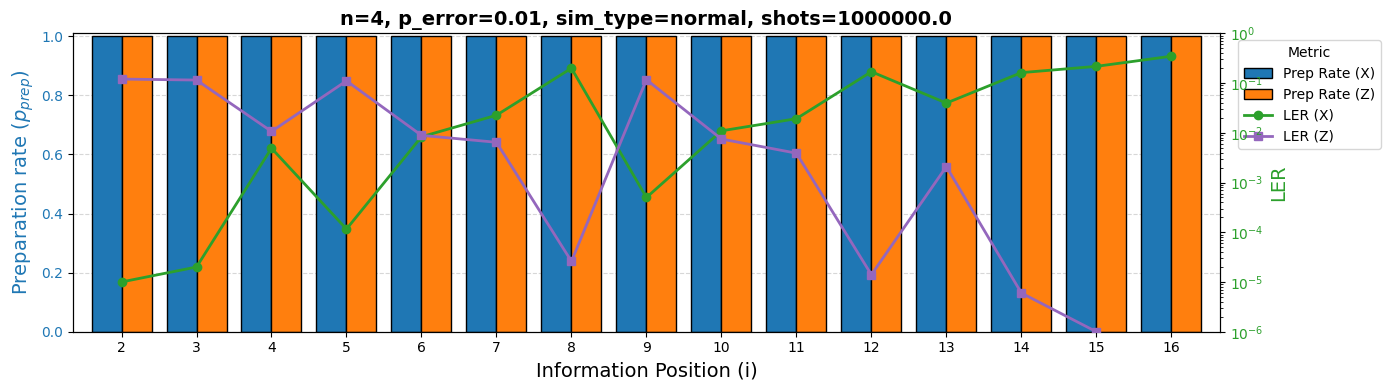

In [76]:
# 2a. Filter the data to a single scenario
# file_path = f"./output/STIM/polar_results.csv"
file_path = f"./output/STIM/polar_results_json_accepted.csv"
n_val = 4
p_error_val = 0.01
sim_type_val = 'normal'
shots_val = 1e6

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-1) # 0.001 n6

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-3, ler_ylim_max=1e-1) # 0.001
plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-6, ler_ylim_max=1e0) # 0.01

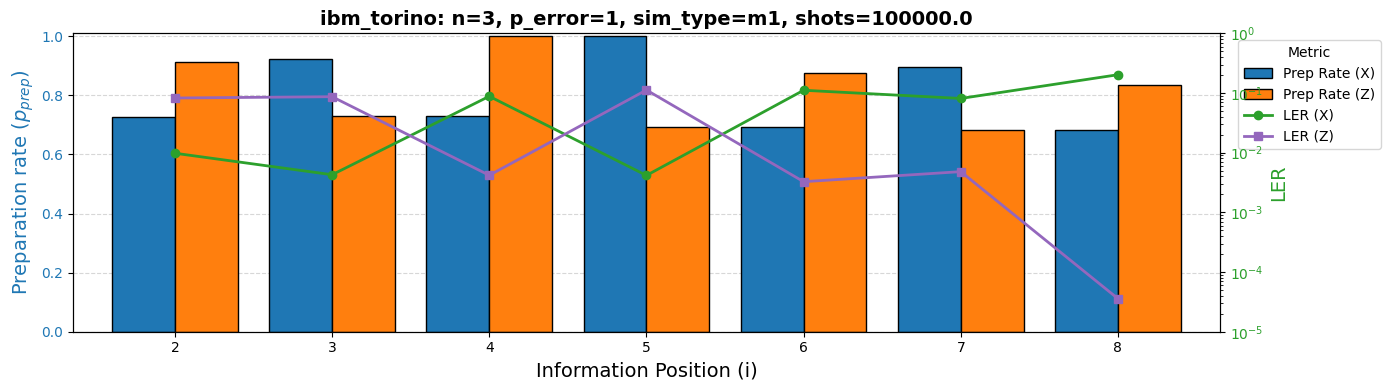

In [77]:
hw_name = "ibm_torino"
file_path = f"./output/STIM/{hw_name}_polar_results_json.csv"
# file_path = f"./output/STIM/polar_results_json.csv"
n_val = 3
p_error_val = 1
sim_type_val = 'm1'
shots_val = 1e5

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, hw_name, ler_ylim_min=5e-6, ler_ylim_max=1e-1) # rate 0.01
# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, hw_name, ler_ylim_min=1e-4, ler_ylim_max=1e0) # rate 0.1
plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, hw_name, ler_ylim_min=1e-5, ler_ylim_max=1e0) # rate 1

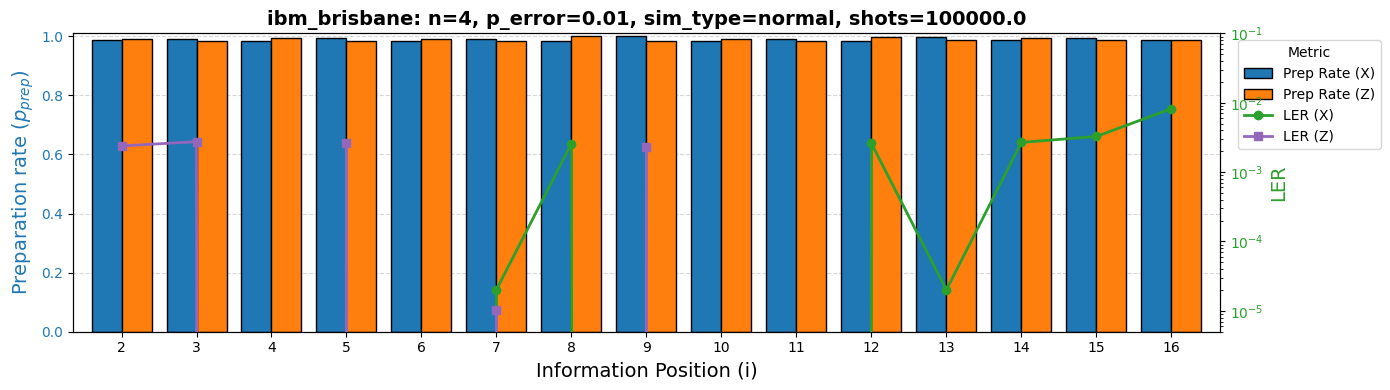

In [78]:
hw_name = "ibm_brisbane"
# 2a. Filter the data to a single scenario
file_path = f"./output/STIM/{hw_name}_polar_results_json.csv"
# file_path = f"./output/STIM/polar_results_json.csv"
n_val = 4
p_error_val = 0.01
sim_type_val = 'normal'
shots_val = 1e5

plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, hw_name, ler_ylim_min=5e-6, ler_ylim_max=1e-1) # rate 0.01
# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, hw_name, ler_ylim_min=1e-4, ler_ylim_max=1e0) # rate 0.1
# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, hw_name, ler_ylim_min=1e-2, ler_ylim_max=1e0) # rate 1

In [79]:
# # --- 2. Data Preparation: Filtering and Pivoting ---

# # A plot cannot easily handle all combinations simultaneously.
# # We first filter the data down to one specific scenario 
# # (e.g., sim_type='normal', fixed p_error, fixed n).

# # 2a. Filter the data to a single scenario
# filtered_df = df[
#     (df['sim_type'] == 'normal') & 
#     (df['p_error'] == p_error_val) &
#     (df['n'] == n_val)
# ].copy()

# # 2b. Group the data 
# # We calculate the average prep_rate and LER for each (i, lstate) combination.
# grouped_data = filtered_df.groupby(['i', 'lstate'])[['prep_rate', 'LER']].mean().reset_index()

# # Apply normalization: prep_rate / 2 (max value is now 1)
# grouped_data['prep_rate'] = grouped_data['prep_rate'] / 2
# # Apply log transformation to LER.
# # We use np.log10 for the logarithmic scale.
# grouped_data['LER_log10'] = np.log10(grouped_data['LER'])

# # 2c. Prepare data for the stacked bar chart (prep_rate by lstate)
# # We transform the 'lstate' values ('x' and 'z') into separate columns.
# pivot_df = grouped_data.pivot(index='i', columns='lstate', values='prep_rate')

# # 2d. Prepare data for the line chart (LER)
# # We calculate the average LER_log10 for each 'i' across all 'lstate' measurements included in the pivot.
# ler_line_data = grouped_data.groupby('i')['LER_log10'].mean() 

# print("--- Pivoted Normalized Prep Rate Data ---")
# print(pivot_df)
# print("\n--- LER Log10 Line Data ---")
# print(ler_line_data)
# print("---------------------------------\n")


# # --- 3. Plotting the Stacked Bar Chart with Secondary Axis ---

# # Set a stylish plotting background
# plt.style.use('seaborn-v0_8-darkgrid') 

# # Create the figure and primary axes (ax1 for prep_rate)
# fig, ax1 = plt.subplots(figsize=(10, 6))

# # Generate the stacked bar plot on the primary axis (ax1)
# bar_container = pivot_df.plot(
#     kind='bar', 
#     stacked=True, 
#     ax=ax1,
#     color=['#1f77b4', '#ff7f0e'], # Custom colors for 'x' and 'z'
#     edgecolor='black',
#     zorder=2 # Ensure bars are below the line
# )

# # Create a secondary axis (ax2 for LER)
# ax2 = ax1.twinx()

# # Plot LER on the secondary axis (ax2) as a line chart
# line_color = '#d62728' # Red color for LER line
# ler_line, = ax2.plot(
#     ax1.get_xticks(), # Align line plot x-ticks with bar plot positions
#     ler_line_data.values, 
#     color=line_color, 
#     marker='o', 
#     linestyle='--', 
#     linewidth=2,
#     zorder=3, # Ensure line is on top of bars
#     label='Logical Error Rate ($\log_{10}$ LER)'
# )

# # --- 4. Customizing Aesthetics ---

# # Primary Axis (Prep Rate) Customization
# ax1.set_title(
#     f'Normalized Prep Rate (Stacked Bars) and $\log_{{10}}$ LER (Line) vs. i \n for n={n_val}, p_error={p_error_val}, sim_type=normal', 
#     fontsize=16, 
#     fontweight='bold'
# )
# ax1.set_xlabel('Index i', fontsize=14)
# ax1.set_ylabel('Normalized Preparation Rate (Prep_Rate / 2)', fontsize=14, color='#1f77b4')
# ax1.tick_params(axis='y', labelcolor='#1f77b4')

# # Secondary Axis (LER) Customization
# ax2.set_ylabel('Logical Error Rate ($\log_{10}$ LER)', fontsize=14, color=line_color)
# ax2.tick_params(axis='y', labelcolor=line_color)

# # X-axis ticks (set to match the 'i' values and rotate for readability)
# ax1.set_xticklabels(pivot_df.index, rotation=0)

# # Combine Legends
# # Get handles and labels for the bar plot (ax1)
# handles1, labels1 = ax1.get_legend_handles_labels()

# # Combine the bar handles with the LER line handle
# combined_handles = handles1 + [ler_line]
# combined_labels = labels1 + [ler_line.get_label()]

# ax1.legend(combined_handles, combined_labels, loc='upper left', title='Metric', fontsize=10)

# # Grid and Layout adjustments
# ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
# ax2.grid(False) # Turn off grid for the secondary axis to avoid clutter

# plt.tight_layout()

# # Show the plot
# plt.show()

## Only for Accepted states

In [80]:
def plot_result_rate_profiling_accepted(file_path, n_val, p_error_val, sim_type_val, shots_val, hw_name=None,
                               ler_ylim_min=None, ler_ylim_max=None):
    """
    Plots the Preparation Rate (Prep_Rate) as a side-by-side bar chart 
    and the Logical Error Rate (LER) as two separate lines (for lstate 'x' and 'z') 
    on a logarithmic scale, both against the Information Position (i).
    """
    df = pd.read_csv(file_path)
    df["prep_rate_real"] = df["shots"] / df["total_meta_shots"]
    

    # 2a. Filter the data to a single scenario
    filtered_df = df[
        (df['sim_type'] == sim_type_val) & 
        (df['p_error'] == p_error_val) &
        (df['shots'] == shots_val) &
        (df['n'] == n_val)
    ].copy()

    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # 2b. Group the data (using sum as per your previous modification)
    grouped_data = filtered_df.groupby(['i', 'lstate'])[['prep_rate_real', 'LER']].sum().reset_index()

    # 2c. Prepare data for the side-by-side bar chart (prep_rate by lstate)
    pivot_df_prep_rate = grouped_data.pivot(index='i', columns='lstate', values='prep_rate_real')

    # 2d. Prepare data for the two LER lines (LER by lstate)
    pivot_df_ler = grouped_data.pivot(index='i', columns='lstate', values='LER')

    # --- 3. Plotting the Grouped Bar Chart with Two Line Plots on Secondary Axis ---

    # # Set a stylish plotting background
    # plt.style.use('seaborn-v0_8-darkgrid') 

    # Create the figure and primary axes (ax1 for prep_rate)
    fig, ax1 = plt.subplots(figsize=(14, 4))

    # Set primary axis limits (Prep Rate)
    ax1.set_ylim(0, 1.01) 

    # Generate the side-by-side bar plot on the primary axis (ax1)
    # KEY CHANGE 1: 'stacked' parameter removed/set to False (default)
    bar_container = pivot_df_prep_rate.plot(
        kind='bar', 
        ax=ax1,
        color={'x': '#1f77b4', 'z': '#ff7f0e'}, # Map colors to lstate
        edgecolor='black',
        zorder=2, 
        width=0.8, # Controls bar width
        rot=0 # Keep x-labels horizontal
    )

    # Create a secondary axis (ax2 for LER)
    ax2 = ax1.twinx()

    # Apply Logarithmic Scale and fixed limits to the LER Y-axis
    ax2.set_yscale('log') 
    if ler_ylim_min is not None or ler_ylim_max is not None:
        ax2.set_ylim(ler_ylim_min, ler_ylim_max) 

    # Plot LER on the secondary axis (ax2) as two line charts
    ler_handles = []
    ler_colors = {'x': '#2ca02c', 'z': '#9467bd'} # Green for x, Purple for z LER
    ler_markers = {'x': 'o', 'z': 's'}

    # KEY CHANGE 2: Plot LER for 'x' and 'z' separately
    for lstate in ['x', 'z']:
        ler_line, = ax2.plot(
            ax1.get_xticks(), 
            pivot_df_ler[lstate].values, 
            color=ler_colors[lstate], 
            marker=ler_markers[lstate], 
            linestyle='-',
            linewidth=2,
            zorder=3, 
            label=f'LER ({lstate.upper()})'
        )
        ler_handles.append(ler_line)

    # --- 4. Customizing Aesthetics ---

    # Title Customization
    title_prefix = f"{hw_name}: " if hw_name else ""
    ax1.set_title(
        f'{title_prefix}n={n_val}, p_error={p_error_val}, sim_type={sim_type_val}, shots={shots_val}', 
        fontsize=14, 
        fontweight='bold'
    )

    # Primary Axis (Prep Rate) Customization
    ax1.set_xlabel('Information Position (i)', fontsize=14)
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', fontsize=14, color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    # Secondary Axis (LER) Customization
    # ax2.set_ylabel('LER ($\log$ Scale)', fontsize=14, color=ler_colors['x']) # Use a single color for the axis label
    ax2.set_ylabel('LER', fontsize=14, color=ler_colors['x']) # Use a single color for the axis label
    ax2.tick_params(axis='y', labelcolor=ler_colors['x'])

    # X-axis ticks (set to match the 'i' values from the pivot index)
    ax1.set_xticklabels(pivot_df_prep_rate.index, rotation=0)

    # Combine and Position Legends
    # FIX: Use .containers to get the distinct color handles for the bar series
    bar_handles = bar_container.containers # Correctly retrieves the two BarContainer objects
    # bar_labels = [f"Prep Rate ({l.upper()})" for l in pivot_df_prep_rate.columns]
    bar_labels = [
        f"Prep Rate (|+>)" if l == 'x' else
        f"Prep Rate (|0>)"
        for l in pivot_df_prep_rate.columns
    ]

    combined_handles = list(bar_handles) + ler_handles
    # combined_labels = bar_labels + [f'LER ({l.upper()})' for l in pivot_df_ler.columns]
    combined_labels = bar_labels + [
        f"LER (|+>)" if l == 'x' else
        f"LER (|0>)"
        for l in pivot_df_ler.columns
    ]
    
    ax1.legend(
        combined_handles, 
        combined_labels, 
        loc='upper left',          
        bbox_to_anchor=(1.03, 1.0), 
        title='Metric', 
        fontsize=10
    )

    # Grid and Layout adjustments
    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax2.grid(False) 

    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM"
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_val}_{shots_val}_accepted.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

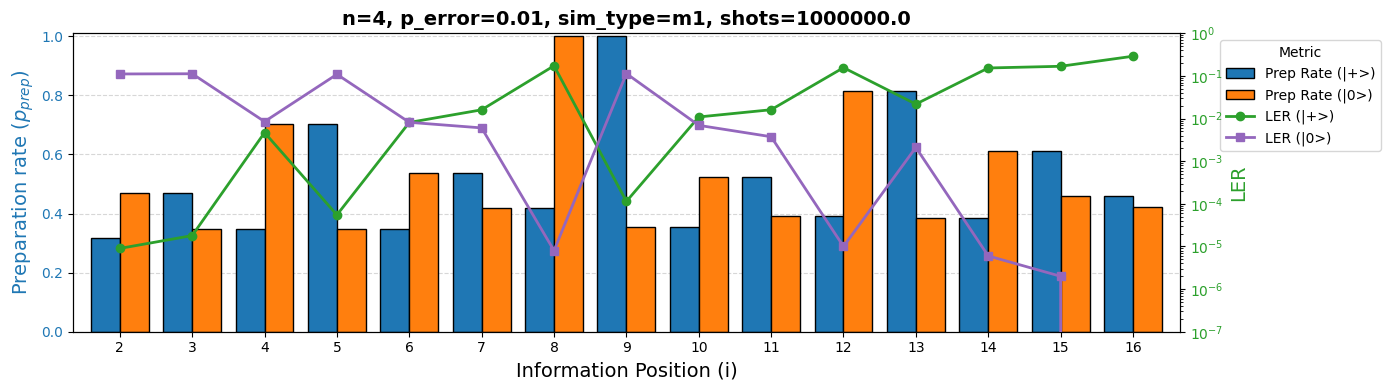

In [81]:
# Result for the only accepted states
file_path = f"./output/STIM/polar_results_json_accepted.csv"
# file_path = f"./output/STIM/polar_results_json.csv"
n_val = 4
p_error_val = 0.01
sim_type_val = 'm1'
shots_val = 1e6

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-1) # 0.001 n6

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-3, ler_ylim_max=1e-1) # 0.001
plot_result_rate_profiling_accepted(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e0) # 0.01

### For Normal Experiment

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val,
                                      i_val, shots_val, hw_name=None,
                                ler_ylim_min=None, ler_ylim_max=None):
    """
    Plots the Preparation Rate (Prep_Rate) and Logical Error Rate (LER) against 
    the Information Position (i), including SEM/SD error bars and horizontal 
    baseline lines for the i=7 values.
    """
    df = pd.read_csv(file_path)

    # 2a. Filter the data to a single scenario
    filtered_df = df[
        (df['sim_type'].isin(sim_type_val)) &
        (df['i'].isin(i_val)) &
        (df['p_error'] == p_error_val) &
        (df['n'] == n_val) &
        (df['lstate'] == lstate_val)
    ].copy()

    # --- Data Preparation ---
    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return
        
    # Helper function to get the correct error column name
    def get_error_col(rate_col, df_cols):
        sem_col = f'{rate_col}_SEM'
        sd_col = f'{rate_col}_SD'
        if sem_col in df_cols:
            return sem_col
        elif sd_col in df_cols:
            return sd_col
        return None

    # Get error columns
    prep_rate_error_col = get_error_col('prep_rate', filtered_df.columns)
    ler_error_col = get_error_col('LER', filtered_df.columns)

    if not prep_rate_error_col or not ler_error_col:
         print("Error: Could not find required error columns (_SEM or _SD).")
         return
    
    # 2c-2f. Prepare DataFrames for plotting
    pivot_df_prep_rate = filtered_df.pivot(index='i', columns='sim_type', values='prep_rate').sort_index(axis=1, ascending=False)
    pivot_df_prep_rate_err = filtered_df.pivot(index='i', columns='sim_type', values=prep_rate_error_col).sort_index(axis=1, ascending=False)
    pivot_df_ler = filtered_df.pivot(index='i', columns='sim_type', values='LER').sort_index(axis=1, ascending=False)
    pivot_df_ler_err = filtered_df.pivot(index='i', columns='sim_type', values=ler_error_col).sort_index(axis=1, ascending=False)


    # --- 3. Plotting the Grouped Bar Chart with Two Line Plots on Secondary Axis ---

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.set_ylim(0, 1.01)

    # Prep Rate Bar Plot (Primary Axis)
    prep_rate_error_values = pivot_df_prep_rate_err.values.T

    bar_container = pivot_df_prep_rate.plot(
        kind='bar',
        ax=ax1,
        yerr=prep_rate_error_values, 
        capsize=3, 
        color={'normal': '#1f77b4', 'm1': '#ff7f0e'},
        edgecolor='black',
        zorder=2,
        width=0.8,
        rot=0
    )

    # LER Line Plot (Secondary Axis)
    ax2 = ax1.twinx()
    ax2.set_yscale('log')
    if ler_ylim_min is not None or ler_ylim_max is not None:
        ax2.set_ylim(ler_ylim_min, ler_ylim_max)
    
    x_positions = ax1.get_xticks()
    ler_handles = []
    ler_colors = {'normal': '#2ca02c', 'm1': '#9467bd'}
    ler_markers = {'normal': 'o', 'm1': 's'}
    bar_width = 0.8 / len(sim_type_val)
    sim_types = list(pivot_df_ler.columns)
    num_sim_types = len(sim_types)

    # offsets = np.linspace(-bar_width / 2, bar_width / 2, num_sim_types)
    offsets = [0]

    for idx, sim_type in enumerate(sim_type_val):
        ler_mean = pivot_df_ler[sim_type].values
        ler_err = pivot_df_ler_err[sim_type].values
        x_line_coords = x_positions + offsets[idx]
        
        ler_line, _, _ = ax2.errorbar(
            x_line_coords, 
            ler_mean,
            yerr=ler_err, 
            fmt=ler_markers[sim_type], 
            color=ler_colors[sim_type],
            linestyle='-',
            linewidth=2,
            capsize=3,
            zorder=3,
            label=f'LER ({sim_type.upper()})'
        )
        ler_handles.append(ler_line)

    # --- NEW MODIFICATION START (Horizontal Baseline Lines for i=7) ---
    
    # Filter the data specifically for i=7
    baseline_df = filtered_df[filtered_df['i'] == 7]
    baseline_handles = []

    if not baseline_df.empty:
        print("Adding horizontal baseline lines for i=7 values.")
        
        for index, row in baseline_df.iterrows():
            sim_type = row['sim_type']
            prep_rate_baseline = row['prep_rate']
            ler_baseline = row['LER']
            
            # 1. Prep Rate Baseline (ax1)
            prep_color = '#1f77b4' if sim_type == 'normal' else '#ff7f0e'
            prep_rate_line = ax1.axhline(
                y=prep_rate_baseline,
                color=prep_color, 
                linestyle=':', 
                linewidth=1, 
                zorder=1,
                label='$p_{prep}$ baseline'
            )
            
            # 2. LER Baseline (ax2)
            ler_color = ler_colors[sim_type]
            ler_line = ax2.axhline(
                y=ler_baseline,
                color=ler_color, 
                linestyle='--', 
                linewidth=1, 
                zorder=1,
                label=f'LER baseline'
            )
            
            # Add line handles for the legend
            baseline_handles.append(prep_rate_line)
            baseline_handles.append(ler_line)

    # --- NEW MODIFICATION END ---

    # --- 4. Customizing Aesthetics and Legend ---

    ax1.set_xlabel('Information Position (i)')
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2.set_ylabel('Logical error rate (LER)', color=ler_colors['m1'])
    ax2.tick_params(axis='y', labelcolor=ler_colors['m1'])

    ax1.set_xticklabels(pivot_df_prep_rate.index, rotation=0)

    # Combine and Position Legends
    bar_handles = [container[0] for container in bar_container.containers]
    bar_handles = [item for item in bar_handles if item is not None]

    bar_labels = [
        "$p_{prep}$ - prop-1" if l == 'm1' else "$p_{prep}$"
        for l in pivot_df_prep_rate.columns
    ]

    ler_labels = [
        f"LER - prop-1" if l == 'm1' else f"LER"
        for l in pivot_df_ler.columns
    ]
    
    # Combine all handles and labels (data points and baselines)
    # combined_handles = list(bar_handles) + ler_handles + baseline_handles
    # combined_labels = bar_labels + ler_labels + [h.get_label() for h in baseline_handles]
    combined_handles = list(bar_handles) + ler_handles
    combined_labels = bar_labels + ler_labels


    ax1.legend(
        combined_handles,
        combined_labels,
        loc='upper left',
        fontsize=10
    )

    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax2.grid(False)

    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM/normal"
    os.makedirs(output_dir, exist_ok=True)

    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    sim_type_str = '_'.join(sim_type_val)
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_str}_{shots_val}_accepted.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [160]:
# Result for the only accepted states
# file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
# file_path = f"./output/STIM/qiskit/n5_result/ibm_torino_polar_results_json_qiskit_n5_combined.csv"
# file_path = f"./output/STIM/polar_results_json.csv"
n_val = 4
p_error_val = 1
sim_type_val = ["normal", 'm1']
i_val = [2, 3, 5, 9, 17]
# i_val = range(2, (2**n_val))
shots_val = 5e6
lstate_val = "x"

# plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-3) # 0.01
plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-3) # 0.005

Adding horizontal baseline lines for i=7 values.


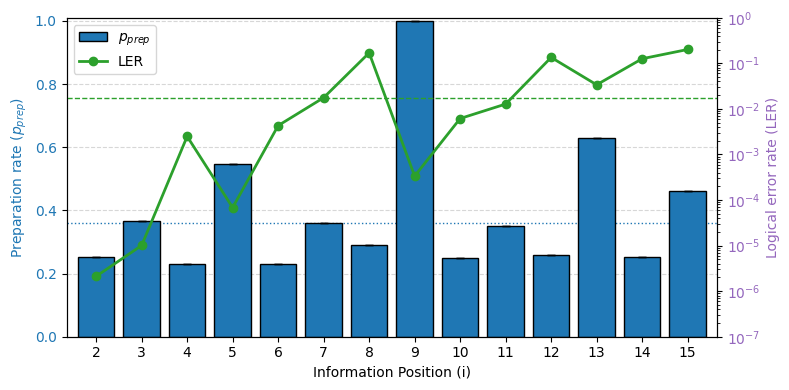

In [161]:
# Result for the only accepted states
# file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
# file_path = f"./output/STIM/qiskit/ibm_torino_polar_results_json_qiskit_n5_combined.csv"
# file_path = f"./output/STIM/polar_results_json.csv"
n_val = 4
# p_error_val = 0.005
p_error_val = 0.01

# p_error_val = 1

sim_type_val = ["normal"]
# i_val = [8, 12, 14, 15]
i_val = range(2, (2**n_val))
lstate_val = "x"

# plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-3) # 0.01
plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-0) # 0.005

ler_handles [<matplotlib.lines.Line2D object at 0x758a012a8190>, <matplotlib.lines.Line2D object at 0x758a012a8690>]
[<ErrorbarContainer object of 3 artists>, <BarContainer object of 4 artists>, <ErrorbarContainer object of 3 artists>, <BarContainer object of 4 artists>]


/tmp/ipykernel_13167/1847158253.py:179: UserWarning: Legend does not support handles for NoneType instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax1.legend(


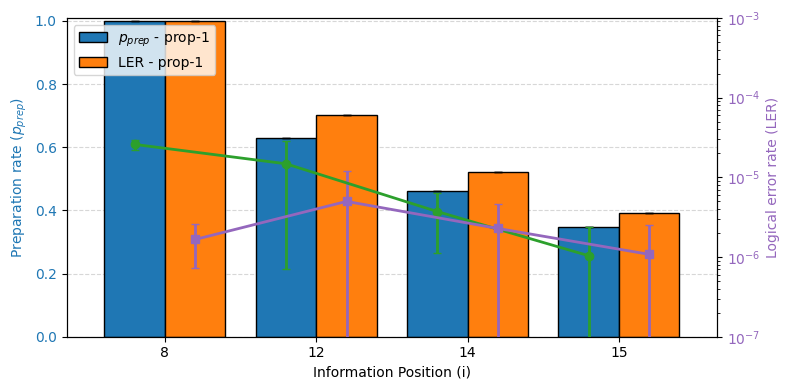

In [116]:
# Result for the only accepted states
# file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
# file_path = f"./output/STIM/qiskit/ibm_torino_polar_results_json_qiskit_n5_combined.csv"
# file_path = f"./output/STIM/polar_results_json.csv"
n_val = 4
# p_error_val = 0.005
p_error_val = 0.01

sim_type_val = ["normal", 'm1']
i_val = [8, 12, 14, 15]
lstate_val = "z"

# plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-3) # 0.01
plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-3) # 0.005

### For PER vs LER

In [85]:
file_path = f"./output/STIM/polar_results_json_accepted.csv"
df = pd.read_csv(file_path)
df["prep_rate_real"] = df["shots"] / df["total_meta_shots"]

df.head()

,n,lstate,i,meas_type,p_error,sim_type,total_meta_shots,shots,count_accept,count_logerror,count_undecided,count_detect_discard,prep_rate,LER,detect_normal,decoding_normal,prep_rate_real
0,3,x,2,"['x', 'x', 'x']",0.010,normal,1650729,1000000,1000000,2330,4513,0,1.0,0.002330,0.955960,0.711931,0.605793
1,3,x,2,"['x', 'x', 'x']",0.001,normal,1052176,1000000,1000000,22,44,0,1.0,0.000022,0.547954,0.371452,0.950411
2,3,x,3,"['z', 'x', 'x']",0.010,normal,1336218,1000000,1000000,5646,10582,0,1.0,0.005646,2.335545,0.762383,0.748381
3,3,x,3,"['z', 'x', 'x']",0.001,normal,1031422,1000000,1000000,56,111,0,1.0,0.000056,0.669521,0.367520,0.969535
4,3,x,4,"['x', 'z', 'x']",0.010,normal,1532169,1000000,1000000,91392,168604,0,1.0,0.091392,9.189724,0.441388,0.652670


In [86]:

# 2a. Filter the data to a single scenario
filtered_df = df[
    (df['shots'] == 1e6) &
    (df['n'] == 4) &
    (df['i'].isin([2, 15])) &
    (df['sim_type'].isin(["normal", "m1"])) &
    (df['LER'] != 0)
].copy()

filtered_df[["n", "lstate", "i", "shots", "p_error", "LER"]]

,n,lstate,i,shots,p_error,LER
84,4,x,2,1000000,0.010,0.000010
110,4,x,15,1000000,0.010,0.216767
111,4,x,15,1000000,0.001,0.027332
114,4,z,2,1000000,0.010,0.120329
115,4,z,2,1000000,0.001,0.013228
140,4,z,15,1000000,0.010,0.000001
144,4,x,2,1000000,0.010,0.000009
170,4,x,15,1000000,0.010,0.168648
171,4,x,15,1000000,0.001,0.019730
174,4,z,2,1000000,0.010,0.111372


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

marker_map = {
        'x': 'o', 'z': 's'
    }
marker_fill_map = {
        'x': 'full', 'z': 'none'
    }
linestyle_map = {
    "normal": '-', "m1": '-.', "m2": ':', 6: '-.'
}

CB_color_cycle_polar = ['#377eb8', '#ff7f00', '#4daf4a',
                '#f781bf', '#a65628', '#984ea3',
                '#999999', '#e41a1c', '#dede00']


def create_figure_peler_accepted(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/"):

    df = pd.read_csv(file_path)
    df["prep_rate_real"] = df["shots"] / df["total_meta_shots"]

    filtered_df = df[
        # (df['n'] == n) &
        # (df['shots'] == shots) &

        (df['n'].isin(n)) &
        (df['lstate'].isin(lstate_values)) &
        (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['LER'] != 0)
    ].copy()

    # --- Define Mapping Dictionaries for Visual Aesthetics (unchanged) ---
    

    # --- Revised Plotting Code ---

    # Create the loglog plot
    # plt.figure(figsize=(14, 6)) 
    plt.figure(figsize=(8, 6)) 

    # 1. Group the filtered data (unchanged)
    grouped = filtered_df.groupby(['n', 'sim_type', 'lstate', 'i'])

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        # label = f'n={n}, {sim_type}, L. {str_log} [i={i}]'
        label = f'n={n}, L. {str_log} [i={i}]'
        
        plt.loglog(
            group_df['p_error'],
            group_df['LER'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label=label
        )

    # 3. Add the x = y guidance line (FIXED and adapted to new limits)
    # Use the desired plot limits to define the guidance line range for best fit
    x_min_limit = 1e-4 # Updated based on your requested x-limit
    x_max_limit = 1e-1
    y_min_limit = 1e-7
    y_max_limit = 1

    # The guidance line should span the desired plot area
    guidance_range = np.logspace(np.log10(min(x_min_limit, y_min_limit)), 
                                np.log10(max(x_max_limit, y_max_limit)), 
                                100) 

    plt.loglog(
        guidance_range,
        guidance_range,
        linestyle=':',    
        color='gray',
        alpha=0.7,
        label='$p = P^L_e$',
    )

    # --- 4. Add the text using plt.text() ---
    # Choose a point (x, y) on the line, e.g., the 50th point (index 49)
    x_coord = guidance_range[55]
    y_coord = guidance_range[53]

    plt.text(
        x_coord,
        y_coord,
        'Diagonal ( y = x )',
        rotation=16,       # Rotate the text to match the 45-degree diagonal line
        ha='center',       # Center the text horizontally on the (x, y) point
        va='bottom',       # Place the text just above the line
        color='gray',      # Match the line color
        fontsize=9
    )


    # 4. Set Axis Limits (NEW) 
    plt.xlim(x_min_limit, x_max_limit)  # x-axis from 1e-4 to 1e-2
    plt.ylim(y_min_limit, y_max_limit)  # y-axis from 1e-7 to 1e-2


    # Set labels and title
    plt.xlabel('Physical error rate ($p$)', fontsize=12)
    plt.ylabel('Logical error rate ($P^L_e$)', fontsize=12)

    # Add grid and legend
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    # Move legend outside to save plot space and use tight_layout
    # plt.legend(loc='best', title='Scenario', bbox_to_anchor=(1.05, 1), borderaxespad=0.) 
    # plt.legend(loc='best', title='Scenario') 
    plt.legend(loc='lower left') 

    # Adjust layout to make room for the legend
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save the figure
    plt.savefig(f'{out_path}polar_peler_accepted_n{n}_{shots}.png')
    # plt.savefig(f'{out_path}_polar_peler_n{n}_{lstate_values[0]}.png')

In [88]:
# # --- Data Loading and Preparation (unchanged) ---
# file_path = f"./output/STIM/polar_results_json_accepted.csv"

# # n = 3
# # shots = 1e6
# # i_values = [2, 4, 5, 7]

# # n = 4
# # shots = 5e6
# # i_values = [2, 4, 6, 7, 13, 15]

# # n = [3]
# # shots = [1e6, 2e6, 5e6]
# # # shots = [5e6]
# # i_values = [2, 4, 5, 6, 7, 13, 15]
# # # i_values = [2, 4, 5, 6, 7, 13, 15]

# n = [4]
# shots = [1e6]
# i_values = [2, 3, 5, 8, 9, 12, 13, 14, 15]
# lstate_values = ["x"]


# sim_type_values = ["m1"]

# create_figure_peler_accepted(file_path, n, lstate_values, shots, i_values, sim_type_values)


In [89]:
def create_figure_peler_normal(file_path, n, lstate_values, i_values, sim_type_values, out_path="./output/STIM/"):

    df = pd.read_csv(file_path)

    filtered_df = df[
        # (df['n'] == n) &
        # (df['shots'] == shots) &
        (df['n'].isin(n)) &
        (df['lstate'].isin(lstate_values)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['LER'] != 0)
    ].copy()

    # --- Define Mapping Dictionaries for Visual Aesthetics (unchanged) ---
    

    # --- Revised Plotting Code ---

    # Create the loglog plot
    # plt.figure(figsize=(14, 6)) 
    plt.figure(figsize=(8, 6)) 

    # 1. Group the filtered data (unchanged)
    grouped = filtered_df.groupby(['n', 'sim_type', 'lstate', 'i'])

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        # label = f'n={n}, {sim_type}, L. {str_log} [i={i}]'
        label = f'n={n}, L. {str_log} [i={i}]'
        
        plt.loglog(
            group_df['p_error'],
            group_df['LER'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label=label
        )

    # 3. Add the x = y guidance line (FIXED and adapted to new limits)
    # Use the desired plot limits to define the guidance line range for best fit
    x_min_limit = 1e-5 # Updated based on your requested x-limit
    x_max_limit = 1e-2
    y_min_limit = 1e-8
    y_max_limit = 1

    # The guidance line should span the desired plot area
    guidance_range = np.logspace(np.log10(min(x_min_limit, y_min_limit)), 
                                np.log10(max(x_max_limit, y_max_limit)), 
                                100) 

    plt.loglog(
        guidance_range,
        guidance_range,
        linestyle=':',    
        color='gray',
        alpha=0.7,
        label='$p = P^L_e$',
    )

    # --- 4. Add the text using plt.text() ---
    # Choose a point (x, y) on the line, e.g., the 50th point (index 49)
    x_coord = guidance_range[55]
    y_coord = guidance_range[53]

    plt.text(
        x_coord,
        y_coord,
        'Diagonal ( y = x )',
        rotation=16,       # Rotate the text to match the 45-degree diagonal line
        ha='center',       # Center the text horizontally on the (x, y) point
        va='bottom',       # Place the text just above the line
        color='gray',      # Match the line color
        fontsize=9
    )


    # 4. Set Axis Limits (NEW) 
    plt.xlim(x_min_limit, x_max_limit)  # x-axis from 1e-4 to 1e-2
    plt.ylim(y_min_limit, y_max_limit)  # y-axis from 1e-7 to 1e-2


    # Set labels and title
    plt.xlabel('Physical error rate ($p$)', fontsize=12)
    plt.ylabel('Logical error rate (LER)', fontsize=12)

    # Add grid and legend
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    # Move legend outside to save plot space and use tight_layout
    # plt.legend(loc='best', title='Scenario', bbox_to_anchor=(1.05, 1), borderaxespad=0.) 
    # plt.legend(loc='best', title='Scenario') 
    plt.legend(loc='lower left') 

    # Adjust layout to make room for the legend
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save the figure
    plt.savefig(f'{out_path}polar_peler_normal_n{n}_{shots}.png')
    # plt.savefig(f'{out_path}_polar_peler_n{n}_{lstate_values[0]}.png')

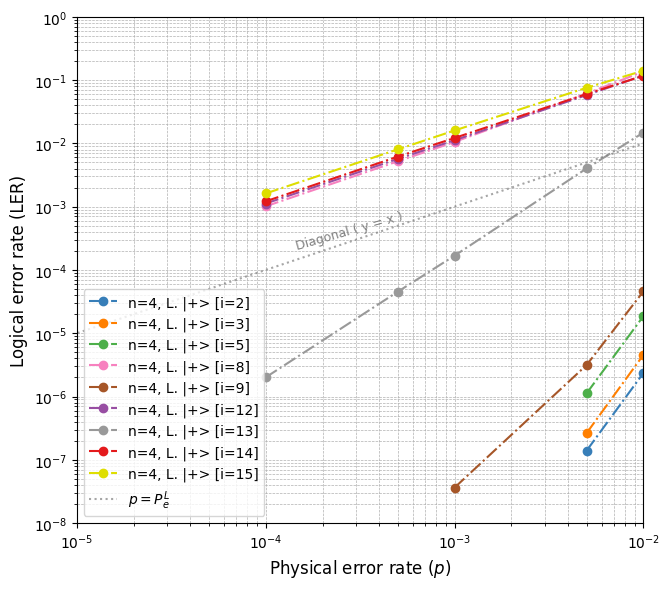

In [91]:
# --- Data Loading and Preparation (unchanged) ---
file_path = f"./output/STIM/normal/polar_results_json_normal_n4_combined.csv"
out_path="./output/STIM/normal/"

# n = 3
# shots = 1e6
# i_values = [2, 4, 5, 7]

# n = 4
# shots = 5e6
# i_values = [2, 4, 6, 7, 13, 15]

# n = [3]
# shots = [1e6, 2e6, 5e6]
# # shots = [5e6]
# i_values = [2, 4, 5, 6, 7, 13, 15]
# # i_values = [2, 4, 5, 6, 7, 13, 15]

n = [4]
i_values = [2, 3, 5, 8, 9, 12, 13, 14, 15]
lstate_values = ["x"]
sim_type_values = ["m1"]

create_figure_peler_normal(file_path, n, lstate_values, i_values, sim_type_values, out_path)


In [ ]:
# def create_figure_peler_accepted_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/"):

#     df = pd.read_csv(file_path)
#     # df["prep_rate_real"] = df["shots"] / df["total_meta_shots"]

#     filtered_df = df[
#         # (df['n'] == n) &
#         # (df['shots'] == shots) &

#         (df['n'].isin(n)) &
#         (df['lstate'].isin(lstate_values)) &
#         (df['shots'].isin(shots)) &
#         (df['i'].isin(i_values)) &
#         (df['sim_type'].isin(sim_type_values)) &
#         (df['LER'] != 0)
#     ].copy()

#     sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

#     # --- Define Mapping Dictionaries for Visual Aesthetics (unchanged) ---
    

#     # --- Revised Plotting Code ---

#     # Create the loglog plot
#     # plt.figure(figsize=(14, 6)) 
#     plt.figure(figsize=(8, 6)) 

#     # 1. Group the filtered data (unchanged)
#     grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])

#     # 2. Iterate through each group and plot it
#     for (n, sim_type, lstate, i), group_df in grouped:
#         marker = marker_map.get(lstate, 'x')  
#         marker_fill = marker_fill_map.get(lstate, 'x')  
#         linestyle = linestyle_map.get(sim_type, 'm1') 
#         color_idx = i_values.index(i)
#         color_style = CB_color_cycle_polar[color_idx]

#         if lstate == "x":
#             str_log = "|+>"
#         else:
#             str_log = "|0>"

#         if sim_type == "m1":
#             str_sim_type = "prop-1"
#         else:
#             str_sim_type = "base"

#         label = f'n={n}, {str_sim_type}, L. {str_log} [i={i}]'
#         # label = f'n={n}, L. {str_log} [i={i}]'
        
#         plt.loglog(
#             group_df['p_error'],
#             group_df['LER'],
#             marker=marker,         
#             linestyle=linestyle,   
#             fillstyle=marker_fill,
#             color=color_style,
#             label=label
#         )

#     # 3. Add the x = y guidance line (FIXED and adapted to new limits)
#     # Use the desired plot limits to define the guidance line range for best fit
#     x_min_limit = 1e-5 # Updated based on your requested x-limit
#     x_max_limit = 1e-2
#     y_min_limit = 1e-7
#     y_max_limit = 1

#     # The guidance line should span the desired plot area
#     guidance_range = np.logspace(np.log10(min(x_min_limit, y_min_limit)), 
#                                 np.log10(max(x_max_limit, y_max_limit)), 
#                                 100) 

#     plt.loglog(
#         guidance_range,
#         guidance_range,
#         linestyle=':',    
#         color='gray',
#         alpha=0.7,
#         label='$p = P^L_e$',
#     )

#     # --- 4. Add the text using plt.text() ---
#     # Choose a point (x, y) on the line, e.g., the 50th point (index 49)
#     x_coord = guidance_range[60]
#     y_coord = guidance_range[58]

#     plt.text(
#         x_coord,
#         y_coord,
#         'Diagonal ( y = x )',
#         rotation=23,       # Rotate the text to match the 45-degree diagonal line
#         ha='center',       # Center the text horizontally on the (x, y) point
#         va='bottom',       # Place the text just above the line
#         color='gray',      # Match the line color
#         fontsize=9
#     )


#     # 4. Set Axis Limits (NEW) 
#     plt.xlim(x_min_limit, x_max_limit)  # x-axis from 1e-4 to 1e-2
#     plt.ylim(y_min_limit, y_max_limit)  # y-axis from 1e-7 to 1e-2


#     # Set labels and title
#     plt.xlabel('Physical error rate ($p$)', fontsize=12)
#     plt.ylabel('Logical error rate ($P^L_e$)', fontsize=12)

#     # Add grid and legend
#     plt.grid(True, which="both", ls="--", linewidth=0.5)
#     # Move legend outside to save plot space and use tight_layout
#     # plt.legend(loc='best', title='Scenario', bbox_to_anchor=(1.05, 1), borderaxespad=0.) 
#     # plt.legend(loc='best', title='Scenario') 
#     plt.legend(loc='lower left') 

#     # Adjust layout to make room for the legend
#     plt.tight_layout(rect=[0, 0, 0.85, 1])

#     # Save the figure
#     plt.savefig(f'{out_path}_polar_peler_n{n}_{lstate_values[0]}.png')

#### Normal Simulation Peler

In [ ]:
import matplotlib.lines as mlines
def create_figure_peler_accepted_normal(file_path, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peler_plot.png"):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        data_label = f'n={n}, L. {str_log} [i={i}]'
        
        # Plot the data
        line, = ax.loglog(
            group_df['p_error'],
            group_df['LER'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 1e-3
    x_max_limit = 1e-2
    y_min_limit = 1e-9
    y_max_limit = 1e-3
    guidance_range = np.logspace(np.log10(min(x_min_limit, y_min_limit)), 
                                np.log10(max(x_max_limit, y_max_limit)), 
                                100) 

    ax.loglog(
        guidance_range,
        guidance_range,
        linestyle=':',    
        color='gray',
        alpha=0.7,
        label='$p = P^L_e$',
    )

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        title="Method",
        loc='upper left',
        bbox_to_anchor=(0.01, 1.0),
        frameon=True,
        edgecolor='black'
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='upper left',
        bbox_to_anchor=(0.01, 0.84), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black'
    )
    
    # --- Remaining Plot Styling (As in original code) ---

    # Add the text using plt.text()
    x_coord = guidance_range[60]
    y_coord = guidance_range[58]

    # ax.text(
    #     x_coord,
    #     y_coord,
    #     'Diagonal ( y = x )',
    #     rotation=23,
    #     ha='center',
    #     va='bottom',
    #     color='gray',
    #     fontsize=9
    # )

    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical error rate ($p$)', fontsize=12)
    ax.set_ylabel('Logical error rate (LER)', fontsize=12)

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save the figure
    # plt.savefig(out_path)
    plt.savefig(f'{out_path}_polar_peler_n{n}_{lstate_values[0]}.png')
    plt.show()

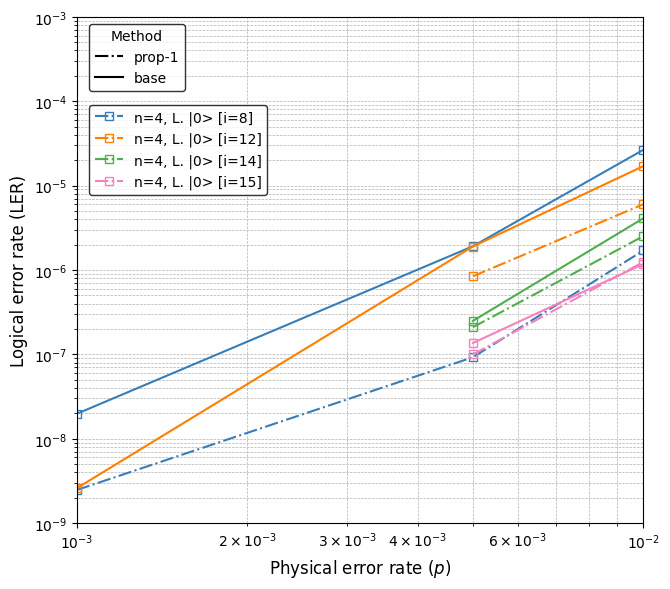

In [ ]:
# --- Data Loading and Preparation (unchanged) ---
# file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"

# n = [3]
# shots = [1e7]
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
# # lstate_values = ["z"]
# # i_values = [2, 4, 5, 6, 7]

n = [4]
# for x
# lstate_values = ["x"]
# # i_values = [2, 3, 4, 5, 8, 9, 13, 15]
# i_values = [2, 3, 5, 9]

# # for z
lstate_values = ["z"]
i_values = [8,12,14,15]

sim_type_values = ["normal", "m1"]

create_figure_peler_accepted_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/")



In [ ]:
import matplotlib.lines as mlines
def create_figure_peler_accepted_qiskit(file_path, hw_name, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peler_plot.png"):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        data_label = f'n={n}, L. {str_log} [i={i}]'
        
        # Plot the data
        line, = ax.loglog(
            group_df['p_error'],
            group_df['LER'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 5e-1
    x_max_limit = 1e-0
    y_min_limit = 1e-9
    y_max_limit = 1e-1
    guidance_range = np.logspace(np.log10(min(x_min_limit, y_min_limit)), 
                                np.log10(max(x_max_limit, y_max_limit)), 
                                100) 

    ax.loglog(
        guidance_range,
        guidance_range,
        linestyle=':',    
        color='gray',
        alpha=0.7,
        label='$p = P^L_e$',
    )

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        title="Method",
        loc='upper left',
        bbox_to_anchor=(0.01, 1.0),
        frameon=True,
        edgecolor='black'
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='upper left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.84), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black'
    )
    
    # --- Remaining Plot Styling (As in original code) ---

    # Add the text using plt.text()
    x_coord = guidance_range[70]
    y_coord = guidance_range[68]

    # ax.text(
    #     x_coord,
    #     y_coord,
    #     'Diagonal ( y = x )',
    #     rotation=21,
    #     ha='center',
    #     va='bottom',
    #     color='gray',
    #     fontsize=9
    # )

    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel(f'Physical error rate scaling factor ({hw_name})', fontsize=12)
    ax.set_ylabel('Logical error rate (LER)', fontsize=12)

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save the figure
    # plt.savefig(out_path)
    plt.savefig(f'{out_path}{hw_name}_polar_peler_n{n_values}_{lstate_values[0]}.png')
    plt.show()
    # Save the figure
    

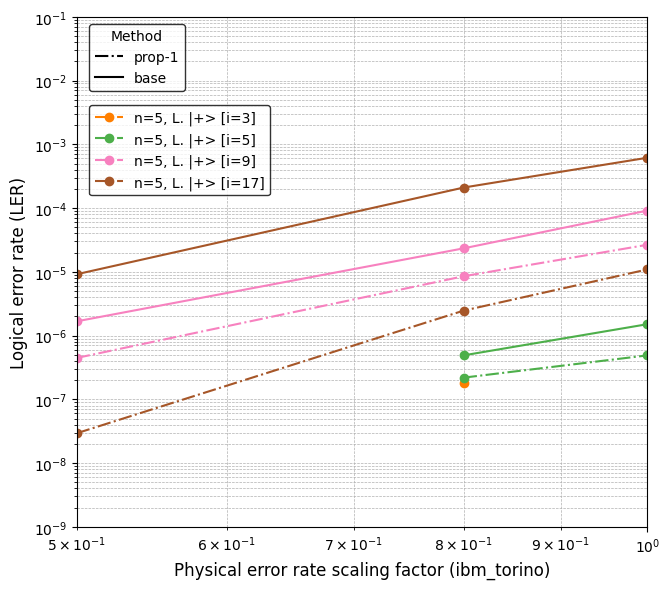

In [ ]:
# --- Data Loading and Preparation (unchanged) ---
hw_name = "ibm_torino"
# file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit.csv"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"

# n = [3]
# shots = [1e7]
# lstate_values = ["x"]
# i_values = [2, 3, 5]
# lstate_values = ["z"]
# i_values = [4, 6, 7]

# n = [4]
# # for x
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9, 17]

# # for z
# lstate_values = ["z"]
# shots = [5e6]
# i_values = [2, 7, 8, 11, 12, 13, 14, 15]

n = [5]
# for x
lstate_values = ["x"]
i_values = [2, 3, 5, 9, 17]



sim_type_values = ["normal", "m1"]

create_figure_peler_accepted_qiskit(file_path, hw_name, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/qiskit/")



#### Only for the accepted state for the prep_rate

In [ ]:
def plot_result_prep_rate_sim_type_comparison(file_path, n_val, p_error_val, lstate_val, 
                                              shots_val, hw_name=None,
                                             ):
    """
    Plots the Preparation Rate (Prep_Rate) comparing 'normal' vs. 'm1' simulation types
    as a side-by-side bar chart, against the Information Position (i).
    """
    df = pd.read_csv(file_path)
    df["prep_rate_real"] = df["shots"] / df["total_meta_shots"]
    

    # 2a. Filter the data to include both 'normal' and 'm1' sim_types, but a SINGLE lstate
    # NOTE: I am fixing the lstate to 'x' here, assuming that's the desired state (| + >)
    filtered_df = df[
        (df['sim_type'].isin(['normal', 'm1'])) & 
        (df['p_error'] == p_error_val) &
        (df['shots'] == shots_val) &
        (df['n'] == n_val) &
        (df['lstate'] == lstate_val) # Filter to a single lstate (e.g., 'x' for |+>)
    ].copy()

    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # 2b. Group the data (using sum as per your previous modification)
    grouped_data = filtered_df.groupby(['i', 'sim_type'])[['prep_rate_real']].sum().reset_index()

    # 2c. Prepare data for the side-by-side bar chart (prep_rate by sim_type)
    # PIVOT using 'sim_type' for columns
    pivot_df_prep_rate = grouped_data.pivot(index='i', columns='sim_type', values='prep_rate_real')

    # Assign Lstate label for title and saving
    lstate_label = "|+>" if lstate_val == 'x' else "|0>"
    
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Set primary axis limits (Prep Rate)
    ax1.set_ylim(0, 1.01) 

    # Plotting the side-by-side bars
    # Use distinct colors for the two sim_types ('normal' and 'm1')
    bar_container = pivot_df_prep_rate.plot(
        kind='bar', 
        ax=ax1,
        color={'normal': '#2ca02c', 'm1': '#9467bd'}, # Example colors for sim_types
        edgecolor='black',
        zorder=2, 
        width=0.8, # Controls bar width
        rot=0 # Keep x-labels horizontal
    )

    # Title Customization
    # title_prefix = f"{hw_name}: " if hw_name else ""
    # ax1.set_title(
    #     f'{title_prefix}n={n_val}, p_error={p_error_val}, lstate={lstate_label}, shots={shots_val}', 
    #     fontsize=14, 
    #     fontweight='bold'
    # )

    # Primary Axis (Prep Rate) Customization
    ax1.set_xlabel('Information Position (i)', )
    ax1.set_ylabel('Preparation rate ($p_{prep}$)',  color='black') # Using black for neutrality
    ax1.tick_params(axis='y', labelcolor='black')

    # X-axis ticks (set to match the 'i' values from the pivot index)
    ax1.set_xticklabels(pivot_df_prep_rate.index, rotation=0)

    # Combine and Position Legends
    bar_handles = bar_container.containers 
    # Label based on sim_type
    # bar_labels = [
    #     f"Prep Rate ({st.upper()})"
    #     for st in pivot_df_prep_rate.columns
    # ]
    bar_labels = [
        f"{st.upper()}"
        for st in pivot_df_prep_rate.columns
    ]


    ax1.legend(
        bar_handles, 
        bar_labels, 
        # fontsize=10,
        # title='Simulation Type'
    )

    # Grid and Layout adjustments
    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM"
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    
    save_path = f"{output_dir}/{filename_prefix}sim_comp_n{n_val}_{p_error_val}_{lstate_val}_{shots_val}_accepted.png"

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

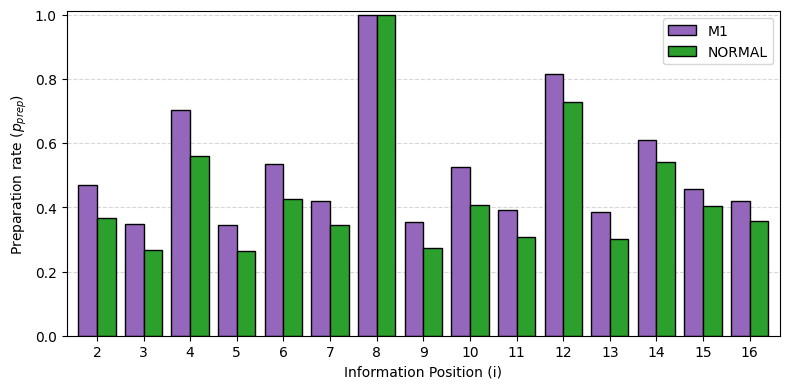

In [ ]:
# Result for the only accepted states
file_path = f"./output/STIM/polar_results_json_accepted.csv"
# file_path = f"./output/STIM/polar_results_json.csv"
n_val = 4
p_error_val = 0.01
sim_type_val = 'm1'
lstate_val = 'z'
shots_val = 1e6

# plot_result_prep_rate_sim_type_comparison(file_path, n_val, p_error_val, lstate_val, shots_val, hw_name=None,
#                                              ler_ylim_min=None, ler_ylim_max=None):

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-1) # 0.001 n6

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-3, ler_ylim_max=1e-1) # 0.001
plot_result_prep_rate_sim_type_comparison(file_path, n_val, p_error_val, lstate_val, shots_val) # 0.01

In [ ]:
def plot_result_prep_rate_sim_type_comparison_normal(file_path, n_val, p_error_val, lstate_val, shots_val, hw_name=None, output_dir = "./output/STIM",
                                             ):
    """
    Plots the Preparation Rate (Prep_Rate) comparing 'normal' vs. 'm1' simulation types
    as a side-by-side bar chart, against the Information Position (i).
    """
    df = pd.read_csv(file_path)
    # df["prep_rate_real"] = df["shots"] / df["total_meta_shots"]
    

    # 2a. Filter the data to include both 'normal' and 'm1' sim_types, but a SINGLE lstate
    # NOTE: I am fixing the lstate to 'x' here, assuming that's the desired state (| + >)
    filtered_df = df[
        (df['sim_type'].isin(['normal', 'm1'])) & 
        (df['p_error'] == p_error_val) &
        (df['shots'] == shots_val) &
        (df['n'] == n_val) &
        (df['lstate'] == lstate_val) # Filter to a single lstate (e.g., 'x' for |+>)
    ].copy()

    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # 2b. Group the data (using sum as per your previous modification)
    grouped_data = filtered_df.groupby(['i', 'sim_type'])[['prep_rate']].sum().reset_index()

    # 2c. Prepare data for the side-by-side bar chart (prep_rate by sim_type)
    # PIVOT using 'sim_type' for columns
    pivot_df_prep_rate = grouped_data.pivot(index='i', columns='sim_type', values='prep_rate')

    # Assign Lstate label for title and saving
    lstate_label = "|+>" if lstate_val == 'x' else "|0>"
    
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Set primary axis limits (Prep Rate)
    ax1.set_ylim(0, 1.01) 

    # Plotting the side-by-side bars
    # Use distinct colors for the two sim_types ('normal' and 'm1')
    bar_container = pivot_df_prep_rate.plot(
        kind='bar', 
        ax=ax1,
        color={'normal': '#2ca02c', 'm1': '#9467bd'}, # Example colors for sim_types
        edgecolor='black',
        zorder=2, 
        width=0.8, # Controls bar width
        rot=0 # Keep x-labels horizontal
    )

    # Title Customization
    # title_prefix = f"{hw_name}: " if hw_name else ""
    # ax1.set_title(
    #     f'{title_prefix}n={n_val}, p_error={p_error_val}, lstate={lstate_label}, shots={shots_val}', 
    #     fontsize=14, 
    #     fontweight='bold'
    # )

    # Primary Axis (Prep Rate) Customization
    ax1.set_xlabel('Information Position (i)', )
    ax1.set_ylabel('Preparation rate ($p_{prep}$)',  color='black') # Using black for neutrality
    ax1.tick_params(axis='y', labelcolor='black')

    # X-axis ticks (set to match the 'i' values from the pivot index)
    ax1.set_xticklabels(pivot_df_prep_rate.index, rotation=0)

    # Combine and Position Legends
    bar_handles = bar_container.containers 
    # Label based on sim_type
    # bar_labels = [
    #     f"Prep Rate ({st.upper()})"
    #     for st in pivot_df_prep_rate.columns
    # ]
    bar_labels = [
        f"{st.upper()}"
        for st in pivot_df_prep_rate.columns
    ]


    ax1.legend(
        bar_handles, 
        bar_labels, 
        # fontsize=10,
        # title='Simulation Type'
    )

    # Grid and Layout adjustments
    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    plt.tight_layout()

    # Save the figure
    
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    
    save_path = f"{output_dir}/{filename_prefix}sim_comp_n{n_val}_{p_error_val}_{lstate_val}_{shots_val}_accepted.png"

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

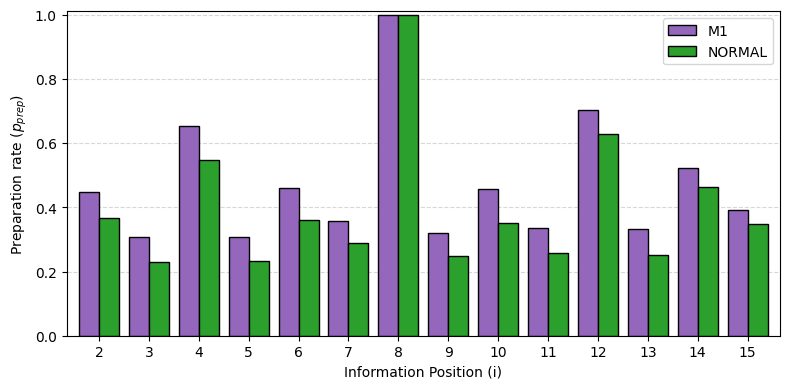

In [ ]:
# Result for the only accepted states
file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
# file_path = f"./output/STIM/polar_results_json.csv"
n_val = 4
p_error_val = 0.01
lstate_val = 'z'
shots_val = 5e6

# plot_result_prep_rate_sim_type_comparison(file_path, n_val, p_error_val, lstate_val, shots_val, hw_name=None,
#                                              ler_ylim_min=None, ler_ylim_max=None):

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-1) # 0.001 n6

# plot_result_rate_profiling(file_path, n_val, p_error_val, sim_type_val, shots_val, ler_ylim_min=1e-3, ler_ylim_max=1e-1) # 0.001
plot_result_prep_rate_sim_type_comparison_normal(file_path, n_val, p_error_val, lstate_val, shots_val, output_dir=f"./output/STIM/normal/") # 0.01

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

marker_map = {
        'x': 'o', 'z': 's'
    }
marker_fill_map = {
        'x': 'full', 'z': 'none'
    }
linestyle_map = {
    "normal": '-', "m1": '-.', "m2": ':', 6: '-.'
}

CB_color_cycle_polar = ['#377eb8', '#ff7f00', '#4daf4a',
                '#f781bf', '#a65628', '#984ea3',
                '#999999', '#e41a1c', '#dede00']


def create_figure_peprep_accepted(file_path, n, shots, i_values, sim_type_values):

    df = pd.read_csv(file_path)
    # Note: 'total_meta_shots' must be a defined column in your CSV
    df["prep_rate_real"] = df["shots"] / df["total_meta_shots"]

    filtered_df = df[
        (df['n'] == n) &
        (df['shots'] == shots) &
        
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
    ].copy()

    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # --- Revised Plotting Code ---

    plt.figure(figsize=(14, 6)) 

    # 1. Group the filtered data (unchanged)
    grouped = filtered_df.groupby(['n', 'sim_type', 'lstate', 'i'])

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        
        # Ensure 'i' is in i_values before indexing, otherwise use 0
        try:
            color_idx = i_values.index(i)
        except ValueError:
            color_idx = 0 
            
        color_style = CB_color_cycle_polar[color_idx % len(CB_color_cycle_polar)]

        str_log = "|+>" if lstate == "x" else "|0>"

        label = f'n={n}, {sim_type}, L. {str_log} [i={i}]'
        
        # *** KEY CHANGE: Use plt.semilogx() for log X and linear Y ***
        plt.semilogx(
            group_df['p_error'],
            group_df['prep_rate_real'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label=label
        )

    # 3. Add the x = y guidance line (Adapted for semi-log plot)
    
    # Define plot limits
    x_min_limit = 1e-4
    x_max_limit = 1e-2
    y_min_limit = 0.0 # Linear Y min
    y_max_limit = 1.0 # Linear Y max


    # 5. Set Axis Limits
    plt.xlim(x_min_limit, x_max_limit)  # x-axis (Log)
    # *** KEY CHANGE: Y-axis limits (Linear) ***
    plt.ylim(y_min_limit, y_max_limit)  # y-axis (Linear)


    # Set labels and title
    # *** KEY CHANGE: Updated Y-axis label to reflect Prep Rate (p_prep) ***
    plt.xlabel('Physical error rate ($p$)', fontsize=12)
    plt.ylabel('Preparation rate ($p_{prep}$)', fontsize=12) 

    # Add grid and legend
    # Use 'both' for x (log) and y (linear) grid lines
    plt.grid(True, which="both", ls="--", linewidth=0.5) 

    # plt.legend(loc='upper left') 
    plt.legend() 

    # Adjust layout
    plt.tight_layout()

    # Save the figure
    plt.savefig(f'./output/STIM/polar_peprep_accepted_n{n}_{shots}_semilog.png')

    plt.show()

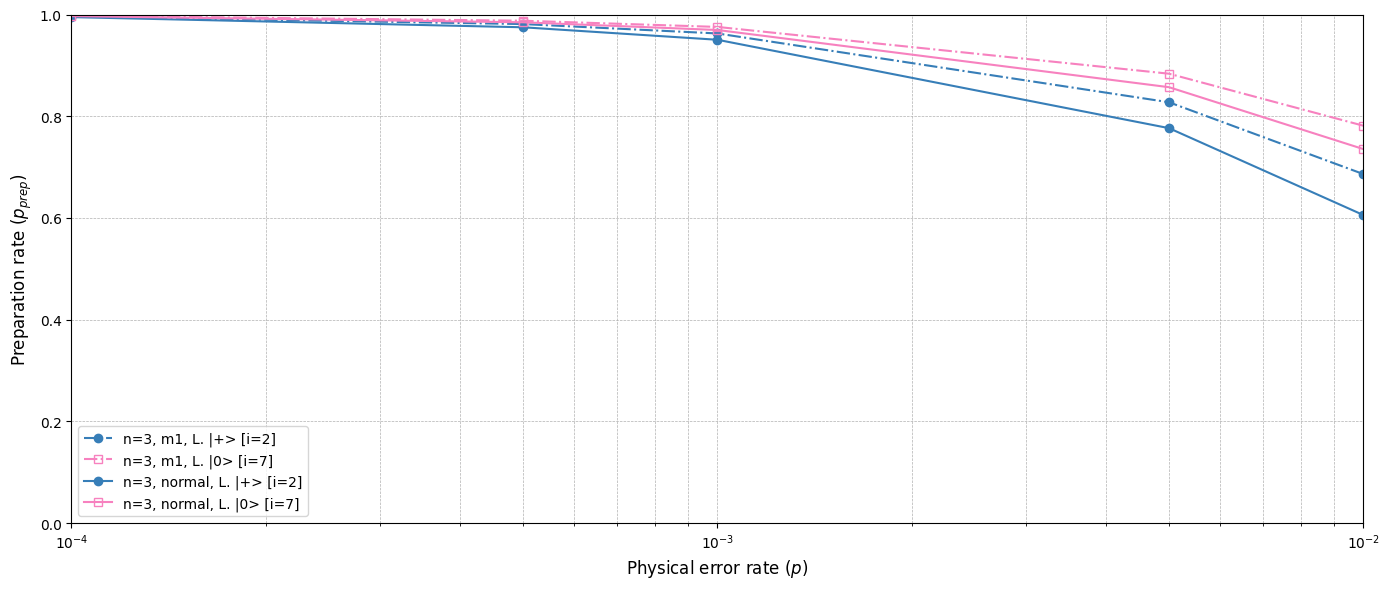

In [ ]:
# --- Data Loading and Preparation (unchanged) ---
file_path = f"./output/STIM/polar_results_json_accepted.csv"

n = 3
shots = 5e6
i_values = [2, 4, 5, 7]

# n = 4
# shots = 2e6
# i_values = [4, 6, 7, 13]

sim_type_values = ["normal", "m1"]

create_figure_peprep_accepted(file_path, n, shots, i_values, sim_type_values)


#### Normal Simulation prep rate

In [ ]:
import matplotlib.lines as mlines
def create_figure_peprep_accepted_normal(file_path, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png"):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        data_label = f'n={n}, L. {str_log} [i={i}]'
        
        # Plot the data
        line, = ax.semilogx(
            group_df['p_error'],
            group_df['prep_rate'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 1e-4
    x_max_limit = 1e-2
    y_min_limit = 0
    y_max_limit = 1.05

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        title="Method",
        loc='upper left',
        bbox_to_anchor=(0.01, 0.6),
        frameon=True,
        edgecolor='black'
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='upper left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.4), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black'
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical error rate ($p$)', fontsize=12)
    ax.set_ylabel('Preparation rate ($p_{prep}$)', fontsize=12)

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save the figure
    # plt.savefig(out_path)
    plt.savefig(f'{out_path}polar_peprep_n{n}_{lstate_values[0]}.png')
    plt.show()

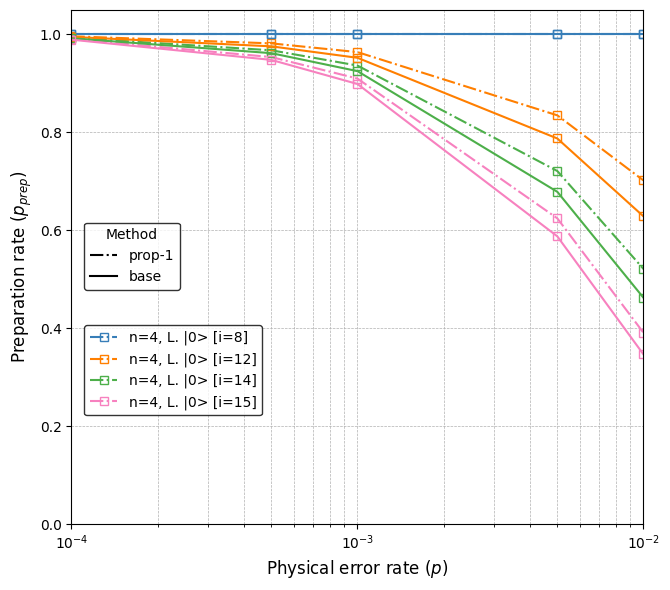

In [ ]:
# --- Data Loading and Preparation (unchanged) ---
# file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
# file_path = f"./output/STIM/normal/n5_result/polar_results_json_normal_n5_combined.csv"

# n = [3]
# shots = [1e7]
# lstate_values = ["x"]
# i_values = [2, 3, 5]
# lstate_values = ["z"]
# i_values = [4, 6, 7]

n = [4]
# # for x
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9, 17]

# for z
lstate_values = ["z"]
i_values = [8, 12, 14, 15]

# n = [5]
# # for x
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9, 17]

# n = [5]
# # for z
# lstate_values = ["z"]
# i_values = [16, 24, 28, 30, 31]


sim_type_values = ["normal", "m1"]

create_figure_peprep_accepted_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/")



In [ ]:
import matplotlib.lines as mlines
def create_figure_peprep_accepted_qiskit(file_path, hw_name, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png"):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        data_label = f'n={n}, L. {str_log} [i={i}]'
        
        # Plot the data
        line, = ax.semilogx(
            group_df['p_error'],
            group_df['prep_rate'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 1e-2
    x_max_limit = 1
    y_min_limit = 0
    y_max_limit = 1.05

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        title="Method",
        loc='upper left',
        bbox_to_anchor=(0.01, 0.6),
        frameon=True,
        edgecolor='black'
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='upper left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.4), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black'
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel(f'Physical error rate scaling factor ({hw_name})', fontsize=12)
    ax.set_ylabel('Preparation rate ($p_{prep}$)', fontsize=12)

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save the figure
    # plt.savefig(out_path)
    plt.savefig(f'{out_path}{hw_name}_polar_peprep_n{n}_{lstate_values[0]}.png')
    plt.show()

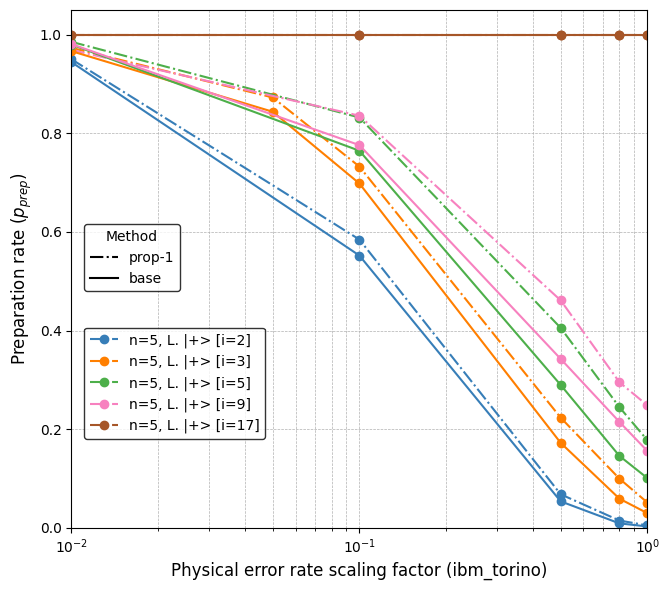

In [ ]:
# --- Data Loading and Preparation (unchanged) ---
hw_name = "ibm_torino"
# file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit.csv"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"

# n = [3]
# # shots = [1e7]
# # lstate_values = ["x"]
# # i_values = [2, 3, 5]
# lstate_values = ["z"]
# i_values = [4, 6, 7]

# n = [4]
# # # # for x
# # # lstate_values = ["x"]
# # # i_values = [2, 3, 5, 9, 17]

# # for z
# lstate_values = ["z"]
# i_values = [8, 12, 14, 15]

n = [5]
# for x
lstate_values = ["x"]
i_values = [2, 3, 5, 9, 17]

# n = [5]
# # for z
# lstate_values = ["z"]
# i_values = [16, 24, 28, 30, 31]



sim_type_values = ["normal", "m1"]

create_figure_peprep_accepted_qiskit(file_path, hw_name, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/qiskit/")



### Pareto Plot

In [ ]:
import numpy as np

def format_to_mathtext(number: float, precision: int = 1) -> str:
    """
    Converts a float to a scientific notation string formatted for Matplotlib's Mathtext (e.g., 10^{-3}).
    
    Args:
        number: The float value to format.
        precision: The number of digits after the decimal point for the coefficient.
        
    Returns:
        A string formatted for Matplotlib/LaTeX rendering.
    """
    # 1. Convert to standard scientific notation (e.g., '1.0e-03')
    # Use f-string formatting with 'e' specifier
    s_standard = f'{number:.{precision}e}'
    
    # 2. Split the coefficient and the exponent
    # Example: '1.0e-03' -> ['1.0', '-03']
    if 'e' in s_standard:
        coefficient, exponent = s_standard.split('e')
    elif 'E' in s_standard:
        coefficient, exponent = s_standard.split('E')
    else:
        # If the number is zero or already formatted without an exponent
        return f'${s_standard}$' 

    # 3. Format the exponent for Mathtext: remove sign if it's '+' and remove leading zeros
    exponent_val = int(exponent)
    
    # 4. Combine the parts into the desired format ($coefficient \times 10^{exponent}$)
    # Note: Use '\times' for the multiplication symbol and '{}' for the superscript.
    
    if exponent_val == 0:
        # If exponent is 0, just show the coefficient
        return f'${coefficient}$'
    elif coefficient == '1' or coefficient == '1.0':
        # Simplify if the coefficient is 1 (e.g., just $10^{-3}$)
        return f'$10^{{{exponent_val}}}$'
    else:
        # Full format: $C \times 10^{E}$
        return f'${coefficient} \\times 10^{{{exponent_val}}}$'


# --- Examples ---
print(f"1e-3 (1e-3) -> {format_to_mathtext(1e-3)}")        # Output: $10^{-3}$
print(f"5.2e-6 (0.0000052) -> {format_to_mathtext(5.2e-6, 1)}") # Output: $5.2 \times 10^{-6}$
print(f"12000 (1.2e+04) -> {format_to_mathtext(12000, 1)}") # Output: $1.2 \times 10^{4}$
print(f"1.0 (1.0) -> {format_to_mathtext(1.0, 1)}")        # Output: $1.0$
print(f"0.00000000321 (3.21e-09) -> {format_to_mathtext(3.21e-09, 2)}") # Output: $3.21 \times 10^{-9}$

1e-3 (1e-3) -> $10^{-3}$
5.2e-6 (0.0000052) -> $5.2 \times 10^{-6}$
12000 (1.2e+04) -> $1.2 \times 10^{4}$
1.0 (1.0) -> $1.0$
0.00000000321 (3.21e-09) -> $3.21 \times 10^{-9}$


In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from typing import List, Dict, Any

# --- Mapping Dictionaries (Improvised based on your style) ---
# Assuming 'label' is in the format 'simtype_i#' (e.g., 'base_i2')

# Map the simulation type from the label to a marker style
MARKER_MAP_PARETO = {"normal": "o", "m1": "s"}

# Map the iteration number ('i#') from the label to a color
# Using standard matplotlib color cycle for simplicity, similar to CB_color_cycle_polar usage
COLOR_MAP_PARETO = {
    2: "C0",
    3: "C1",
    5: "C2",
    9: "C3",
    17: "C4",
    8: "C5",
    12: "C6",
    14: "C7",
    15: "C8",
}

def create_figure_pareto_prep_vs_ler(
    file_path,
    n_values,
    lstate_values,
    i_values,
    sim_type_values,
    expected_error_targets: List[float] = [1e2, 1e3, 1e4, 1e5, 1e6],
    ler_ylim: List[float] = [1e-3, 1e-3],
    out_path: str = "pareto_plot.png",
):
    """
    Generates a Pareto plot comparing Attempts per successful prepared state (1/p_prep)
    against the Logical Error Rate (LER), including iso-contours for expected errors.

    Args:
        df: DataFrame containing 'label', 'p_prep', and 'LER' columns.
        shots: The total number of shots used for the experiment.
        expected_error_targets: List of target expected error counts for the contours.
        ler_ylim: The min/max limits for the y-axis (LER).
        out_path: The filename to save the resulting plot.
    """

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        (df['p_error'] != 0.05) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # # --- Data Pre-processing ---
    # if not all(col in df.columns for col in REQUIRED_COLUMNS):
    #     raise ValueError(f"DataFrame must contain columns: {REQUIRED_COLUMNS}")

    df["attempts_per_success"] = 1.0 / df["prep_rate"]
    # # Add columns for plotting logic
    # df["kind"] = df["sim_type"].apply(lambda x: "prop" if "prop" in x.lower() else "base")
    # df["ipos"] = df["sim_type"].apply(lambda x: x.split("_")[-1])

    # --- Calculate Iso-Contours ---
    # Define x-range for plotting
    x_min_data = df["attempts_per_success"].min()
    x_max_data = df["attempts_per_success"].max()
    x_min_limit = x_min_data * 0.95
    x_max_limit = x_max_data * 1.05
    x_vals = np.linspace(x_min_limit, x_max_limit, 200)

    # print(df[["n", "i", "sim_type", "attempts_per_success", "kind", "ipos"]])

    # LER = (Expected Errors / Shots) * (1 / p_prep)
    # LER = (Expected Errors / Shots) * Attempts per Success
    contours: Dict[float, Any] = {}
    shots = 1e8
    for t in expected_error_targets:
        # LER values for the given x_vals (Attempts per Success)
        contours[t] = (t / shots) * x_vals

    # --- Plotting Setup ---
    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    # --- 1. Plot Iso-Contours ---
    contour_handles = []
    contour_labels = []
    for t, ler_vals in contours.items():
        # Plot the contours
        line, = ax.plot(
            x_vals,
            ler_vals,
            linestyle="--",
            linewidth=1,
            # color="gray", # Use a neutral color for contours
            label='_nolegend_'
        )
        # Collect handles/labels for the contour legend
        contour_handles.append(line)
        shots_str = "{:.{}e}".format(shots, 0)
        # contour_labels.append(f"Expected Errors: {int(t):,} ({shots_str}) shots)")
        # contour_labels.append(f"{int(t):,}")
        contour_labels.append(f"{format_to_mathtext(t,0)}")
        


    # --- 2. Plot Data Points (Scatter) ---
    # Legend proxies setup
    kind_proxies = {}  # For 'sim_type' (base/prop) legend (Markers)
    ipos_proxies = {}  # For 'i' position legend (Colors)
    
    # Iterate over data points
    for _, row in df.iterrows():
        kind = row["sim_type"]
        ipos = row["i"]
        marker = MARKER_MAP_PARETO.get(kind, 'o')
        color = COLOR_MAP_PARETO.get(ipos, 'k')

        # Scatter plot the data point
        ax.scatter(
            row["attempts_per_success"],
            row["LER"],
            s=120,
            marker=marker,
            color=color,
            edgecolor="k",
            zorder=5,
            label='_nolegend_' # Prevent auto-legend inclusion
        )

        # Annotate the point label for clarity (as in your example)
        ax.annotate(
            # "{:.{}e}".format(row["p_error"], 0),
            format_to_mathtext(row["p_error"], 0),
            (row["attempts_per_success"] * 1.02, row["LER"] * 1.15),
            fontsize=9
        )

        # Collect proxies for the two legends
        if kind not in kind_proxies:
            # Create a simple scatter proxy for the marker style
            proxy = mlines.Line2D(
                [], [],
                color='k',
                marker=marker,
                linestyle='None',
                markersize=8,
                label=kind.capitalize()
            )
            kind_proxies[kind] = proxy

        if ipos not in ipos_proxies:
            # Create a simple line/point proxy for the color
            proxy = mlines.Line2D(
                [], [],
                color=color,
                marker='o',
                linestyle='None',
                markersize=8,
                label=f'i={ipos}'
            )
            ipos_proxies[ipos] = proxy

    # --- 3. Create and Place Legends ---

    # Legend A: Iso-Contours
    legend_a = ax.legend(
        contour_handles,
        contour_labels,
        title=f"Exp. err in {format_to_mathtext(shots,0)} shots",
        loc="lower right",
        fontsize=9,
        bbox_to_anchor=(1.0, 0.0),
        frameon=True,
        edgecolor='black'
    )
    # Add Legend A back to the axes
    ax.add_artist(legend_a)

    # Legend B: Simulation Type (Marker)
    kind_handles = list(kind_proxies.values())
    kind_labels = ["prop-1" if p.get_label() == "M1" else "base" for p in kind_handles] # Use labels set during proxy creation
    # kind_labels = [p.get_label() for p in kind_handles] # Use labels set during proxy creation

    legend_b = ax.legend(
        kind_handles,
        kind_labels,
        # title="Method",
        loc="upper right",
        fontsize=9,
        bbox_to_anchor=(0.78, 1.0), # Positioned below Legend A
        frameon=True,
        edgecolor='black'
    )
    # Add Legend B back to the axes
    ax.add_artist(legend_b)

    # Legend C: Data Series (Color)
    ipos_handles = list(ipos_proxies.values())
    if lstate_values[0].lower() == "x" :
        log_str = "+"
    else:
        log_str = "0"
    ipos_labels = [f"n={n_values[0]}, L.|{log_str}> [{p.get_label()}]" for p in ipos_handles] # Use labels set during proxy creation

    # # Sort the i-values numerically for better legend order
    # ipos_labels, ipos_handles = zip(*sorted(zip(ipos_labels, ipos_handles), key=lambda x: int(x[0].split('=')[-1])))
    

    ax.legend(
        ipos_handles,
        ipos_labels,
        # title="Iteration (i)",
        loc="upper right",
        fontsize=9,
        bbox_to_anchor=(0.99, 1), # Positioned below Legend B
        frameon=True,
        edgecolor='black'
    )

    # # --- 4. Styling and Layout ---
    ax.set_xscale("linear")
    # ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([x_min_limit, x_max_limit])
    ax.set_ylim(ler_ylim)

    ax.set_xlabel("Attempts per successful prepared state ($1 / p_{prep}$)", fontsize=12)
    ax.set_ylabel("Logical error rate (LER)", fontsize=12)
    # ax.set_title(f"Pareto Plot: Attempts-per-Success vs LER (shots = {int(shots):,})")
    
    ax.grid(which="major", linestyle=":", linewidth=0.7, alpha=0.7)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

    plt.tight_layout()

    # --- 5. Save and Show ---
    # plt.savefig(out_path, dpi=200)
    plt.savefig(f'{out_path}polar_pareto_n{n_values[0]}_{lstate_values[0]}.png', dpi=200)
    plt.show()

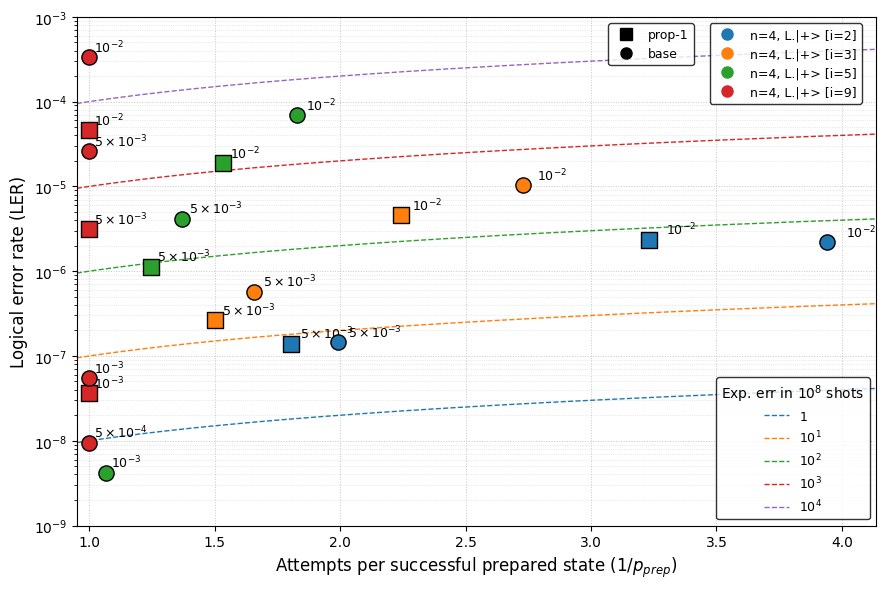

In [ ]:
# --- Data Loading and Preparation (unchanged) ---
hw_name = "ibm_torino"
# file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit.csv"
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
# file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
expected_error_targets: List[float] = [1, 1e1, 1e2, 1e3, 1e4]
ler_ylim: List[float] = [1e-9, 1e-3]

# n = [3]
# # shots = [1e7]
# # lstate_values = ["x"]
# # i_values = [2, 3, 5]
# lstate_values = ["z"]
# i_values = [4, 6, 7]

n = [4]
# for x
lstate_values = ["x"]
i_values = [2, 3, 5, 9, 17]

# # for z
# lstate_values = ["z"]
# i_values = [8, 12, 14, 15]

# n = [5]
# # for x
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9, 17]

# n = [5]
# # for z
# lstate_values = ["z"]
# i_values = [16, 24, 28, 30, 31]



sim_type_values = ["normal", "m1"]




# create_figure_lerpareto_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/")
create_figure_pareto_prep_vs_ler(file_path, n, lstate_values, i_values, sim_type_values, expected_error_targets, ler_ylim, out_path="./output/STIM/normal/")

In [ ]:
def create_figure_pareto_prep_vs_ler_qiskit(
    file_path,
    hw_name,
    n_values,
    lstate_values,
    i_values,
    sim_type_values,
    expected_error_targets: List[float] = [1e2, 1e3, 1e4, 1e5, 1e6],
    ler_ylim: List[float] = [1e-3, 1e-3],
    out_path: str = "pareto_plot.png",
):
    """
    Generates a Pareto plot comparing Attempts per successful prepared state (1/p_prep)
    against the Logical Error Rate (LER), including iso-contours for expected errors.

    Args:
        df: DataFrame containing 'label', 'p_prep', and 'LER' columns.
        shots: The total number of shots used for the experiment.
        expected_error_targets: List of target expected error counts for the contours.
        ler_ylim: The min/max limits for the y-axis (LER).
        out_path: The filename to save the resulting plot.
    """

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['p_error'] != 0.05) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # # --- Data Pre-processing ---
    # if not all(col in df.columns for col in REQUIRED_COLUMNS):
    #     raise ValueError(f"DataFrame must contain columns: {REQUIRED_COLUMNS}")

    df["attempts_per_success"] = 1.0 / df["prep_rate"]
    # # Add columns for plotting logic
    # df["kind"] = df["sim_type"].apply(lambda x: "prop" if "prop" in x.lower() else "base")
    # df["ipos"] = df["sim_type"].apply(lambda x: x.split("_")[-1])

    # --- Calculate Iso-Contours ---
    # Define x-range for plotting
    x_min_data = df["attempts_per_success"].min()
    x_max_data = df["attempts_per_success"].max()
    x_min_limit = x_min_data * 0.95
    # x_max_limit = x_max_data * 1.05
    x_max_limit = 12
    x_vals = np.linspace(x_min_limit, x_max_limit, 200)

    # print(df[["n", "i", "sim_type", "attempts_per_success", "kind", "ipos"]])

    # LER = (Expected Errors / Shots) * (1 / p_prep)
    # LER = (Expected Errors / Shots) * Attempts per Success
    contours: Dict[float, Any] = {}
    shots = 1e8
    for t in expected_error_targets:
        # LER values for the given x_vals (Attempts per Success)
        contours[t] = (t / shots) * x_vals

    # --- Plotting Setup ---
    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    # --- 1. Plot Iso-Contours ---
    contour_handles = []
    contour_labels = []
    for t, ler_vals in contours.items():
        # Plot the contours
        line, = ax.plot(
            x_vals,
            ler_vals,
            linestyle="--",
            linewidth=1,
            # color="gray", # Use a neutral color for contours
            label='_nolegend_'
        )
        # Collect handles/labels for the contour legend
        contour_handles.append(line)
        shots_str = "{:.{}e}".format(shots, 0)
        # contour_labels.append(f"Expected Errors: {int(t):,} ({shots_str}) shots)")
        # contour_labels.append(f"{int(t):,}")
        contour_labels.append(f"{format_to_mathtext(t,0)}")
        


    # --- 2. Plot Data Points (Scatter) ---
    # Legend proxies setup
    kind_proxies = {}  # For 'sim_type' (base/prop) legend (Markers)
    ipos_proxies = {}  # For 'i' position legend (Colors)
    
    # Iterate over data points
    for _, row in df.iterrows():
        kind = row["sim_type"]
        ipos = row["i"]
        marker = MARKER_MAP_PARETO.get(kind, 'o')
        color = COLOR_MAP_PARETO.get(ipos, 'k')

        # Scatter plot the data point
        ax.scatter(
            row["attempts_per_success"],
            row["LER"],
            s=120,
            marker=marker,
            color=color,
            edgecolor="k",
            zorder=5,
            label='_nolegend_' # Prevent auto-legend inclusion
        )

        # Annotate the point label for clarity (as in your example)
        ax.annotate(
            # "{:.{}e}".format(row["p_error"], 0),
            format_to_mathtext(row["p_error"], 0),
            (row["attempts_per_success"] * 1.02, row["LER"] * 1.15),
            fontsize=9
        )

        # Collect proxies for the two legends
        if kind not in kind_proxies:
            # Create a simple scatter proxy for the marker style
            proxy = mlines.Line2D(
                [], [],
                color='k',
                marker=marker,
                linestyle='None',
                markersize=8,
                label=kind.capitalize()
            )
            kind_proxies[kind] = proxy

        if ipos not in ipos_proxies:
            # Create a simple line/point proxy for the color
            proxy = mlines.Line2D(
                [], [],
                color=color,
                marker='o',
                linestyle='None',
                markersize=8,
                label=f'i={ipos}'
            )
            ipos_proxies[ipos] = proxy

    # --- 3. Create and Place Legends ---

    # Legend A: Iso-Contours
    legend_a = ax.legend(
        contour_handles,
        contour_labels,
        title=f"Exp. err in {format_to_mathtext(shots,0)} shots",
        loc="lower right",
        fontsize=9,
        bbox_to_anchor=(1.0, 0.0),
        frameon=True,
        edgecolor='black'
    )
    # Add Legend A back to the axes
    ax.add_artist(legend_a)

    # Legend B: Simulation Type (Marker)
    kind_handles = list(kind_proxies.values())
    kind_labels = ["prop-1" if p.get_label() == "M1" else "base" for p in kind_handles] # Use labels set during proxy creation
    # kind_labels = [p.get_label() for p in kind_handles] # Use labels set during proxy creation

    legend_b = ax.legend(
        kind_handles,
        kind_labels,
        # title="Method",
        loc="upper right",
        fontsize=9,
        bbox_to_anchor=(0.78, 1.0), # Positioned below Legend A
        frameon=True,
        edgecolor='black'
    )
    # Add Legend B back to the axes
    ax.add_artist(legend_b)

    # Legend C: Data Series (Color)
    ipos_handles = list(ipos_proxies.values())
    if lstate_values[0].lower() == "x" :
        log_str = "+"
    else:
        log_str = "0"
    ipos_labels = [f"n={n_values[0]}, L.|{log_str}> [{p.get_label()}]" for p in ipos_handles] # Use labels set during proxy creation

    # # Sort the i-values numerically for better legend order
    # ipos_labels, ipos_handles = zip(*sorted(zip(ipos_labels, ipos_handles), key=lambda x: int(x[0].split('=')[-1])))
    

    ax.legend(
        ipos_handles,
        ipos_labels,
        # title="Iteration (i)",
        loc="upper right",
        fontsize=9,
        bbox_to_anchor=(0.99, 1), # Positioned below Legend B
        frameon=True,
        edgecolor='black'
    )

    # # --- 4. Styling and Layout ---
    ax.set_xscale("linear")
    # ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([x_min_limit, x_max_limit])
    ax.set_ylim(ler_ylim)

    ax.set_xlabel("Attempts per successful prepared state ($1 / p_{prep}$)", fontsize=12)
    ax.set_ylabel("Logical error rate (LER)", fontsize=12)
    # ax.set_title(f"Pareto Plot: Attempts-per-Success vs LER (shots = {int(shots):,})")
    
    ax.grid(which="major", linestyle=":", linewidth=0.7, alpha=0.7)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

    plt.tight_layout()

    # --- 5. Save and Show ---
    # plt.savefig(out_path, dpi=200)
    plt.savefig(f'{out_path}{hw_name}_polar_pareto_n{n_values[0]}_{lstate_values[0]}.png', dpi=200)
    plt.show()

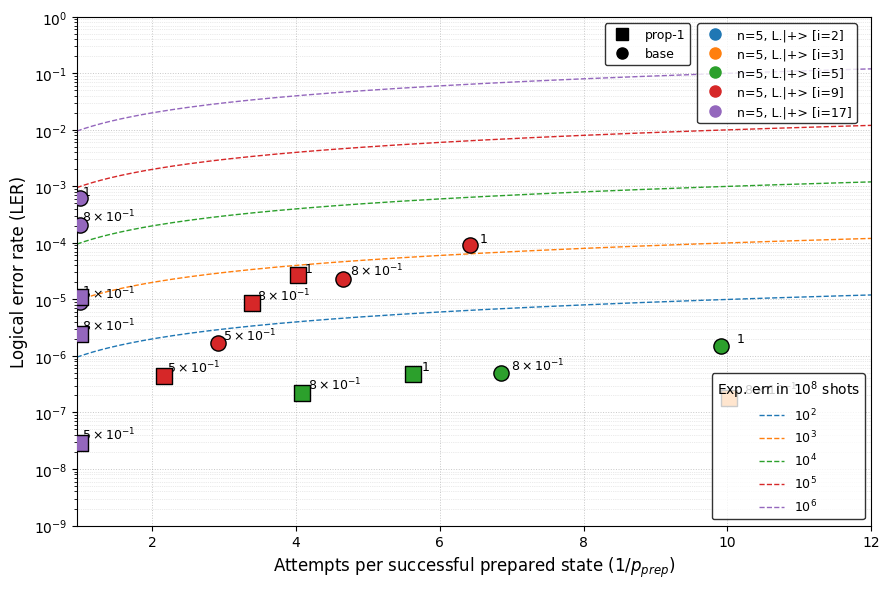

In [ ]:
# --- Data Loading and Preparation (unchanged) ---
hw_name = "ibm_torino"
# file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit.csv"
# file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
expected_error_targets: List[float] = [1e2, 1e3, 1e4, 1e5, 1e6]
ler_ylim: List[float] = [1e-9, 1e-0]

# n = [3]
# # shots = [1e7]
# # lstate_values = ["x"]
# # i_values = [2, 3, 5]
# lstate_values = ["z"]
# i_values = [4, 6, 7]

# n = [4]
# # for x
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9, 17]

# # for z
# lstate_values = ["z"]
# i_values = [8, 12, 14, 15]

n = [5]
# for x
lstate_values = ["x"]
i_values = [2, 3, 5, 9, 17]

# n = [5]
# # for z
# lstate_values = ["z"]
# i_values = [16, 24, 28, 30, 31]



sim_type_values = ["normal", "m1"]




# create_figure_lerpareto_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/")
create_figure_pareto_prep_vs_ler_qiskit(file_path, hw_name, n, lstate_values, i_values, sim_type_values, expected_error_targets, ler_ylim, out_path="./output/STIM/normal/")

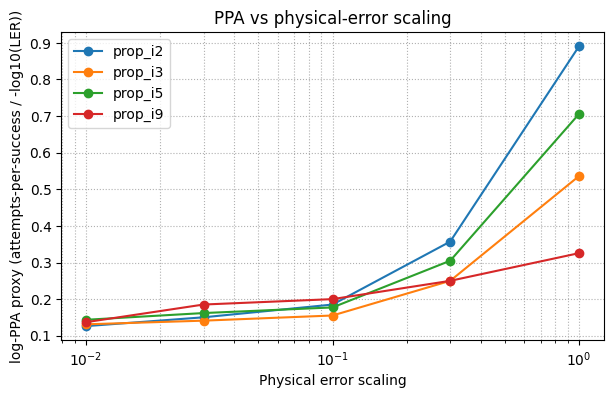

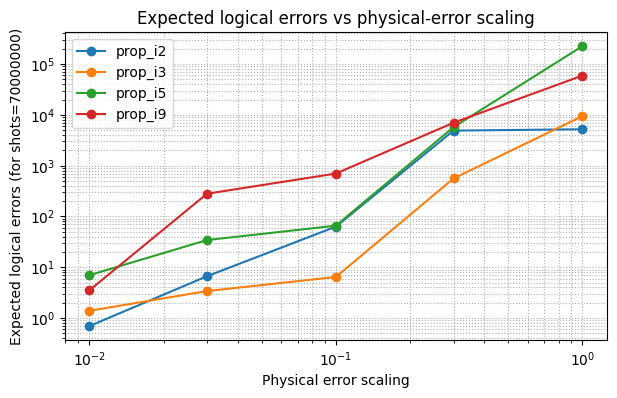

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Example input format:
# scalings = [0.01, 0.03, 0.1, 0.3, 1.0]  # physical error scale points
# For each candidate, provide arrays for p_prep(scalings) and LER(scalings)

shots = 7e7
scalings = np.array([0.01, 0.03, 0.1, 0.3, 1.0])

# Replace these dictionaries with your exact arrays (length must match scalings)
# Example placeholders (dummy values) - replace!
candidates = {
    "prop_i2": {"p_prep": np.array([0.99,0.95,0.9,0.7,0.31]), "LER": np.array([1e-8,1e-7,1e-6,1e-4,2.4e-4])},
    "prop_i3": {"p_prep": np.array([0.99,0.97,0.92,0.8,0.52]), "LER": np.array([2e-8,5e-8,1e-7,1e-5,2.6e-4])},
    "prop_i5": {"p_prep": np.array([0.995,0.98,0.94,0.82,0.62]), "LER": np.array([1e-7,5e-7,1e-6,1e-4,5.2e-3])},
    "prop_i9": {"p_prep": np.array([1.0,1.0,1.0,1.0,1.0]), "LER": np.array([5e-8,4e-6,1e-5,1e-4,8.5e-4])},
}

# compute metrics
df_rows = []
for name, dat in candidates.items():
    p = np.array(dat["p_prep"])
    l = np.array(dat["LER"])
    att_per_succ = 1.0 / p
    logPPA = att_per_succ / (-np.log10(l))   # recommended metric
    successes = p * shots
    expected_errors = successes * l
    for s, a,succ,ee in zip(scalings, att_per_succ, successes, expected_errors):
        df_rows.append({"candidate": name, "scaling": s, "attempts_per_success": a,
                        "logPPA": (a / (-np.log10(l[np.where(scalings==s)[0][0]]))),
                        "successes": succ, "expected_errors": ee, "LER": l[np.where(scalings==s)[0][0]]})

df = pd.DataFrame(df_rows)

# Plot log-PPA vs scaling
plt.figure(figsize=(7,4))
for name in candidates.keys():
    sub = df[df['candidate']==name]
    plt.plot(sub['scaling'], sub['logPPA'], marker='o', label=name)
plt.xscale('log')
plt.xlabel('Physical error scaling')
plt.ylabel('log-PPA proxy (attempts-per-success / -log10(LER))')
plt.title('PPA vs physical-error scaling')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

# Plot expected errors vs scaling for fixed shot budget
plt.figure(figsize=(7,4))
for name in candidates.keys():
    sub = df[df['candidate']==name]
    plt.plot(sub['scaling'], sub['expected_errors'], marker='o', label=name)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical error scaling')
plt.ylabel(f'Expected logical errors (for shots={int(shots)})')
plt.title('Expected logical errors vs physical-error scaling')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()
